# Deep Learning 

## AAPL 5-Day Forward Return Prediction

This notebook implements chronological deep learning models for AAPL 5-day forward return prediction.

In [1]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# PYTORCH ENVIRONMENT CHECK

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader

    print("PyTorch version:", torch.__version__)
    print("PyTorch available")

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu")

    print("Device:", device)

except ImportError:
    print("PyTorch is NOT installed.")

PyTorch is NOT installed.


In [3]:
%pip install torch torchvision

  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
   ---------------------------------------- 0.0/124.1 MB ? eta -:--:--
   ---------------------------------------- 1.0/124.1 MB 4.1 MB/s eta 0:00:31
    --------------------------------------- 2.4/124.1 MB 4.2 MB/s eta 0:00:29
   - -------------------------------------- 3.1/124.1 MB 4.2 MB/s eta 0:00:29
   - -------------------------------------- 4.2/124.1 MB 4.1 MB/s eta 0:00:30
   - -------------------------------------- 5.2/124.1 MB 4.1 MB/s eta 0:00:29
   - -------------------------------------- 6.0/124.1 MB 4.2 MB/s eta 0:00:29
   -- ------------------------------------- 7.1/124.1 MB 4.2 MB/s eta 0:00:29
   -- ------------------------------------- 7.9/124.1 MB 4.2 MB/s eta 0:00:28
   -- ------------------------------------- 8.9/124.1 MB 4.3 MB/s eta 0:00:27
   --- ------------------------------------ 9.7/124.1 MB 4.3 MB/s eta 0:00:27
   --- ------------------------------------ 10.7/124.1 MB 4.3 MB/s eta 0:00:27
   --

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

print("PyTorch version:", torch.__version__)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch available")
print("Device:", device)

PyTorch version: 2.14.0+cpu
PyTorch available
Device: cpu


In [5]:
PROJECT_ROOT = Path(
    r"C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor")

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "aapl_features_with_target.parquet")

df_dl = pd.read_parquet(DATA_PATH)

df_dl["date"] = pd.to_datetime(df_dl["date"])
df_dl = df_dl.sort_values("date").reset_index(drop=True)

In [6]:
print("Dataset shape:", df_dl.shape)
print("Date range:", df_dl["date"].min(), "to", df_dl["date"].max())
print("Target available:", "future_return_5d" in df_dl.columns)

Dataset shape: (2931, 291)
Date range: 2015-01-02 00:00:00 to 2026-08-28 00:00:00
Target available: True


In [7]:
# DEEP LEARNING SEQUENCE CONFIGURATION

SEQUENCE_LENGTH = 60
TARGET_COLUMN = "future_return_5d"

LEAKAGE_COLUMNS = [
    "target",
    "future_return_5d"]

# Numeric features only
DL_FEATURE_COLUMNS = [
    col for col in df_dl.columns
    if col not in ["date", *LEAKAGE_COLUMNS]
    and pd.api.types.is_numeric_dtype(df_dl[col])]

In [8]:
print("Sequence length:", SEQUENCE_LENGTH)
print("Number of DL features:", len(DL_FEATURE_COLUMNS))
print("Target:", TARGET_COLUMN)

Sequence length: 60
Number of DL features: 288
Target: future_return_5d


In [9]:
# CHRONOLOGICAL TRAIN / VALIDATION / TEST SPLIT

n = len(df_dl)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df_dl.iloc[:train_end].copy()
val_df = df_dl.iloc[train_end:val_end].copy()
test_df = df_dl.iloc[val_end:].copy()

In [10]:
print("TRAIN:", train_df.shape)
print("VALIDATION:", val_df.shape)
print("TEST:", test_df.shape)

print("\nDate ranges:")
print("Train:", train_df["date"].min(), "→", train_df["date"].max())
print("Validation:", val_df["date"].min(), "→", val_df["date"].max())
print("Test:", test_df["date"].min(), "→", test_df["date"].max())

TRAIN: (2051, 291)
VALIDATION: (440, 291)
TEST: (440, 291)

Date ranges:
Train: 2015-01-02 00:00:00 → 2023-02-24 00:00:00
Validation: 2023-02-27 00:00:00 → 2024-11-22 00:00:00
Test: 2024-11-25 00:00:00 → 2026-08-28 00:00:00


In [11]:
# TRAIN-ONLY FEATURE SCALING

from sklearn.preprocessing import StandardScaler

scaler_dl = StandardScaler()

scaler_dl.fit(
    train_df[DL_FEATURE_COLUMNS])

X_train_scaled = scaler_dl.transform(
    train_df[DL_FEATURE_COLUMNS])

X_val_scaled = scaler_dl.transform(
    val_df[DL_FEATURE_COLUMNS])

X_test_scaled = scaler_dl.transform(
    test_df[DL_FEATURE_COLUMNS])

print("Training scaler fitted successfully")

print("Train scaled shape:", X_train_scaled.shape)
print("Validation scaled shape:", X_val_scaled.shape)
print("Test scaled shape:", X_test_scaled.shape)

Training scaler fitted successfully
Train scaled shape: (2051, 288)
Validation scaled shape: (440, 288)
Test scaled shape: (440, 288)


In [12]:
# CREATE CONTINUOUS-RETURN SEQUENCES

def create_return_sequences(X, y, dates, sequence_length=60):
    """
    Create rolling sequences for deep-learning regression.

    X:
        Scaled feature matrix.

    y:
        Continuous future 5-day return.

    dates:
        Corresponding dates for each target observation.
    """

    X_sequences = []
    y_sequences = []
    sequence_dates = []

    for i in range(sequence_length, len(X)):
        X_sequences.append(
            X[i - sequence_length:i])

        y_sequences.append(
            y[i])

        sequence_dates.append(
            dates.iloc[i])

    return (
        np.asarray(X_sequences, dtype=np.float32),
        np.asarray(y_sequences, dtype=np.float32),
        pd.Series(sequence_dates).reset_index(drop=True))


X_train_seq, y_train_seq, train_seq_dates = create_return_sequences(
    X_train_scaled,
    train_df[TARGET_COLUMN].values,
    train_df["date"],
    SEQUENCE_LENGTH)

X_val_seq, y_val_seq, val_seq_dates = create_return_sequences(
    X_val_scaled,
    val_df[TARGET_COLUMN].values,
    val_df["date"],
    SEQUENCE_LENGTH)

X_test_seq, y_test_seq, test_seq_dates = create_return_sequences(
    X_test_scaled,
    test_df[TARGET_COLUMN].values,
    test_df["date"],
    SEQUENCE_LENGTH)

print("Sequence creation successful")

Sequence creation successful


In [13]:
print("\nTrain:", X_train_seq.shape, y_train_seq.shape)
print("Validation:", X_val_seq.shape, y_val_seq.shape)
print("Test:", X_test_seq.shape, y_test_seq.shape)


Train: (1991, 60, 288) (1991,)
Validation: (380, 60, 288) (380,)
Test: (380, 60, 288) (380,)


In [14]:
# CONVERT SEQUENCES TO PYTORCH TENSORS

# Convert NumPy arrays to PyTorch tensors
X_train_tensor = torch.tensor(
    X_train_seq,
    dtype=torch.float32)

y_train_tensor = torch.tensor(
    y_train_seq,
    dtype=torch.float32
).view(-1, 1)

X_val_tensor = torch.tensor(
    X_val_seq,
    dtype=torch.float32)

y_val_tensor = torch.tensor(
    y_val_seq,
    dtype=torch.float32
).view(-1, 1)

X_test_tensor = torch.tensor(
    X_test_seq,
    dtype=torch.float32)

y_test_tensor = torch.tensor(
    y_test_seq,
    dtype=torch.float32
).view(-1, 1)

print("PyTorch tensors created successfully")

PyTorch tensors created successfully


In [15]:
print("X_train:", X_train_tensor.shape)
print("y_train:", y_train_tensor.shape)

print("X_val:", X_val_tensor.shape)
print("y_val:", y_val_tensor.shape)

print("X_test:", X_test_tensor.shape)
print("y_test:", y_test_tensor.shape)

X_train: torch.Size([1991, 60, 288])
y_train: torch.Size([1991, 1])
X_val: torch.Size([380, 60, 288])
y_val: torch.Size([380, 1])
X_test: torch.Size([380, 60, 288])
y_test: torch.Size([380, 1])


In [16]:
# PYTORCH DATALOADERS

BATCH_SIZE = 32

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False)

print("DataLoaders created successfully")
print("Batch size:", BATCH_SIZE)
print("Shuffle: False")

DataLoaders created successfully
Batch size: 32
Shuffle: False


In [18]:
# LSTM MODEL ARCHITECTURE

class LSTMRegressor(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size=64,
        num_layers=2,
        dropout=0.2
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0)

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(
            hidden_size,
            1)

    def forward(self, x):

        output, (hidden, cell) = self.lstm(x)

        last_output = output[:, -1, :]

        last_output = self.dropout(
            last_output)

        prediction = self.fc(
            last_output)

        return prediction


INPUT_SIZE = X_train_seq.shape[2]

lstm_model = LSTMRegressor(
    input_size=INPUT_SIZE,
    hidden_size=64,
    num_layers=2,
    dropout=0.2
).to(device)

print(lstm_model)
print("\nInput features:", INPUT_SIZE)
print("Device:", device)

LSTMRegressor(
  (lstm): LSTM(288, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Input features: 288
Device: cpu


In [19]:
# LSTM TRAINING SETUP

import copy
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    lstm_model.parameters(),
    lr=0.001,
    weight_decay=1e-5)

MAX_EPOCHS = 50
PATIENCE = 7

print("Loss function: MSELoss")
print("Optimizer: Adam")
print("Learning rate: 0.001")
print("Maximum epochs:", MAX_EPOCHS)
print("Early stopping patience:", PATIENCE)
print("Training setup ready")

Loss function: MSELoss
Optimizer: Adam
Learning rate: 0.001
Maximum epochs: 50
Early stopping patience: 7
Training setup ready


In [21]:
# Check NaN and Inf in scaled sequence data

print("X_train NaN:", np.isnan(X_train_seq).sum())
print("X_train Inf:", np.isinf(X_train_seq).sum())

print("X_val NaN:", np.isnan(X_val_seq).sum())
print("X_val Inf:", np.isinf(X_val_seq).sum())

print("X_test NaN:", np.isnan(X_test_seq).sum())
print("X_test Inf:", np.isinf(X_test_seq).sum())

print("y_train NaN:", np.isnan(y_train_seq).sum())
print("y_train Inf:", np.isinf(y_train_seq).sum())

print("y_val NaN:", np.isnan(y_val_seq).sum())
print("y_val Inf:", np.isinf(y_val_seq).sum())

print("y_test NaN:", np.isnan(y_test_seq).sum())
print("y_test Inf:", np.isinf(y_test_seq).sum())

X_train NaN: 289962
X_train Inf: 0
X_val NaN: 0
X_val Inf: 0
X_test NaN: 0
X_test Inf: 0
y_train NaN: 0
y_train Inf: 0
y_val NaN: 0
y_val Inf: 0
y_test NaN: 0
y_test Inf: 0


In [22]:
nan_counts = train_df[DL_FEATURE_COLUMNS].isna().sum()
nan_features = nan_counts[nan_counts > 0].sort_values(ascending=False)

print("Number of features containing NaN:", len(nan_features))
print("\nTop NaN features:")
print(nan_features.head(20))

Number of features containing NaN: 192

Top NaN features:
Features_JPM_ma_200             199
Features_AAPL_ma_200            199
Features_MSFT_ma_200            199
Features_JNJ_price_to_ma200     199
Features_PG_price_to_ma200      199
Features_CAT_price_to_ma200     199
Features_KO_price_to_ma200      199
Features_NVDA_price_to_ma200    199
Features_KO_ma_200              199
Features_CAT_ma_200             199
Features_AAPL_price_to_ma200    199
Features_HD_ma_200              199
Features_PG_ma_200              199
Features_NVDA_ma_200            199
Features_JNJ_ma_200             199
Features_HD_price_to_ma200      199
Features_MSFT_price_to_ma200    199
Features_JPM_price_to_ma200     199
Features_XOM_price_to_ma200     199
Features_XOM_ma_200             199
dtype: int64


In [23]:
# Remove rows where any modeling feature is unavailable.

DL_REQUIRED_COLUMNS = DL_FEATURE_COLUMNS + [TARGET_COLUMN]

df_dl_clean = df_dl.dropna(subset=DL_REQUIRED_COLUMNS).copy()

df_dl_clean = df_dl_clean.sort_values("date").reset_index(drop=True)

print("Original rows:", len(df_dl))
print("Clean rows:", len(df_dl_clean))
print("Rows removed:", len(df_dl) - len(df_dl_clean))

print("\nRemaining NaNs in features:",
      df_dl_clean[DL_FEATURE_COLUMNS].isna().sum().sum())

print("Remaining NaNs in target:",
      df_dl_clean[TARGET_COLUMN].isna().sum())

Original rows: 2931
Clean rows: 2732
Rows removed: 199

Remaining NaNs in features: 0
Remaining NaNs in target: 0


In [24]:
# Re-create chronological train / validation / test split

n = len(df_dl_clean)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df_dl_clean.iloc[:train_end].copy()
val_df = df_dl_clean.iloc[train_end:val_end].copy()
test_df = df_dl_clean.iloc[val_end:].copy()

print("Train:", len(train_df),
      train_df["date"].min().date(), "→", train_df["date"].max().date())

print("Validation:", len(val_df),
      val_df["date"].min().date(), "→", val_df["date"].max().date())

print("Test:", len(test_df),
      test_df["date"].min().date(), "→", test_df["date"].max().date())

Train: 1912 2015-10-16 → 2023-05-22
Validation: 410 2023-05-23 → 2025-01-08
Test: 410 2025-01-10 → 2026-08-28


In [25]:
from sklearn.preprocessing import StandardScaler

scaler_dl = StandardScaler()

# Fit ONLY on training data
scaler_dl.fit(train_df[DL_FEATURE_COLUMNS])

X_train_scaled = scaler_dl.transform(train_df[DL_FEATURE_COLUMNS])
X_val_scaled = scaler_dl.transform(val_df[DL_FEATURE_COLUMNS])
X_test_scaled = scaler_dl.transform(test_df[DL_FEATURE_COLUMNS])

print("Scaled shapes:")
print("Train:", X_train_scaled.shape)
print("Val:", X_val_scaled.shape)
print("Test:", X_test_scaled.shape)

Scaled shapes:
Train: (1912, 288)
Val: (410, 288)
Test: (410, 288)


In [26]:
X_train_seq, y_train_seq, train_seq_dates = create_return_sequences(
    X_train_scaled,
    train_df[TARGET_COLUMN].values,
    train_df["date"],
    sequence_length=SEQUENCE_LENGTH
)

X_val_seq, y_val_seq, val_seq_dates = create_return_sequences(
    X_val_scaled,
    val_df[TARGET_COLUMN].values,
    val_df["date"],
    sequence_length=SEQUENCE_LENGTH
)

X_test_seq, y_test_seq, test_seq_dates = create_return_sequences(
    X_test_scaled,
    test_df[TARGET_COLUMN].values,
    test_df["date"],
    sequence_length=SEQUENCE_LENGTH
)

print("Train:", X_train_seq.shape, y_train_seq.shape)
print("Val:", X_val_seq.shape, y_val_seq.shape)
print("Test:", X_test_seq.shape, y_test_seq.shape)

Train: (1852, 60, 288) (1852,)
Val: (350, 60, 288) (350,)
Test: (350, 60, 288) (350,)


In [27]:
print("NaN check after cleaning:")

print("X_train:", np.isnan(X_train_seq).sum())
print("X_val:", np.isnan(X_val_seq).sum())
print("X_test:", np.isnan(X_test_seq).sum())

print("y_train:", np.isnan(y_train_seq).sum())
print("y_val:", np.isnan(y_val_seq).sum())
print("y_test:", np.isnan(y_test_seq).sum())

NaN check after cleaning:
X_train: 0
X_val: 0
X_test: 0
y_train: 0
y_val: 0
y_test: 0


In [29]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Recreate tensors from the CLEAN sequences
X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_seq, dtype=torch.float32).view(-1, 1)

X_val_tensor = torch.tensor(X_val_seq, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_seq, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_seq, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_seq, dtype=torch.float32).view(-1, 1)

# Datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# No shuffling — chronological order
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train tensor:", X_train_tensor.shape, y_train_tensor.shape)
print("Val tensor:", X_val_tensor.shape, y_val_tensor.shape)
print("Test tensor:", X_test_tensor.shape, y_test_tensor.shape)
print("Batch size:", BATCH_SIZE)
print("Shuffle: False")

Train tensor: torch.Size([1852, 60, 288]) torch.Size([1852, 1])
Val tensor: torch.Size([350, 60, 288]) torch.Size([350, 1])
Test tensor: torch.Size([350, 60, 288]) torch.Size([350, 1])
Batch size: 32
Shuffle: False


In [30]:
import torch.nn as nn

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class LSTMRegressor(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size=64,
        num_layers=2,
        dropout=0.2
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        output, (hidden, cell) = self.lstm(x)

        # Last timestep
        last_output = output[:, -1, :]

        last_output = self.dropout(last_output)

        prediction = self.fc(last_output)

        return prediction


INPUT_SIZE = X_train_seq.shape[2]

lstm_model = LSTMRegressor(
    input_size=INPUT_SIZE,
    hidden_size=64,
    num_layers=2,
    dropout=0.2
).to(device)

print(lstm_model)
print("\nDevice:", device)
print("Input features:", INPUT_SIZE)

LSTMRegressor(
  (lstm): LSTM(288, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Device: cpu
Input features: 288


In [31]:
# Sanity check: one clean batch through the model

X_batch, y_batch = next(iter(train_loader))

X_batch = X_batch.to(device)
y_batch = y_batch.to(device)

with torch.no_grad():
    test_output = lstm_model(X_batch)

print("Input shape:", X_batch.shape)
print("Target shape:", y_batch.shape)
print("Output shape:", test_output.shape)

print("\nInput contains NaN:", torch.isnan(X_batch).any().item())
print("Input contains Inf:", torch.isinf(X_batch).any().item())

print("Output contains NaN:", torch.isnan(test_output).any().item())
print("Output contains Inf:", torch.isinf(test_output).any().item())

print("\nSample predictions:")
print(test_output[:5].cpu().numpy().flatten())

Input shape: torch.Size([32, 60, 288])
Target shape: torch.Size([32, 1])
Output shape: torch.Size([32, 1])

Input contains NaN: False
Input contains Inf: False
Output contains NaN: False
Output contains Inf: False

Sample predictions:
[0.15397377 0.12941787 0.10879353 0.14834279 0.09320309]


In [32]:
import copy

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    lstm_model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

MAX_EPOCHS = 50
PATIENCE = 7

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

for epoch in range(1, MAX_EPOCHS + 1):

    # -------------------------
    # Training
    # -------------------------
    lstm_model.train()

    running_train_loss = 0.0
    train_samples = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = lstm_model(X_batch)

        loss = criterion(predictions, y_batch)

        loss.backward()

        # Gradient clipping for stable training
        torch.nn.utils.clip_grad_norm_(
            lstm_model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        running_train_loss += loss.item() * X_batch.size(0)
        train_samples += X_batch.size(0)

    epoch_train_loss = running_train_loss / train_samples

    # -------------------------
    # Validation
    # -------------------------
    lstm_model.eval()

    running_val_loss = 0.0
    val_samples = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = lstm_model(X_batch)

            loss = criterion(predictions, y_batch)

            running_val_loss += loss.item() * X_batch.size(0)
            val_samples += X_batch.size(0)

    epoch_val_loss = running_val_loss / val_samples

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {epoch_train_loss:.6f} | "
        f"Val Loss: {epoch_val_loss:.6f}"
    )

    # -------------------------
    # Early stopping
    # -------------------------
    if epoch_val_loss < best_val_loss:

        best_val_loss = epoch_val_loss

        best_model_state = copy.deepcopy(
            lstm_model.state_dict()
        )

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:

            print(
                f"\nEarly stopping triggered at epoch {epoch}"
            )

            break


# Restore best validation model
if best_model_state is not None:

    lstm_model.load_state_dict(best_model_state)

    print("\nBest validation loss:", best_val_loss)
    print("Best LSTM model restored.")

else:

    raise RuntimeError(
        "No valid model checkpoint was created.")

Epoch 01 | Train Loss: 0.005933 | Val Loss: 0.004140
Epoch 02 | Train Loss: 0.002925 | Val Loss: 0.001726
Epoch 03 | Train Loss: 0.002881 | Val Loss: 0.001806
Epoch 04 | Train Loss: 0.002899 | Val Loss: 0.001528
Epoch 05 | Train Loss: 0.001773 | Val Loss: 0.001162
Epoch 06 | Train Loss: 0.001497 | Val Loss: 0.001136
Epoch 07 | Train Loss: 0.001367 | Val Loss: 0.001796
Epoch 08 | Train Loss: 0.001274 | Val Loss: 0.002055
Epoch 09 | Train Loss: 0.001286 | Val Loss: 0.001126
Epoch 10 | Train Loss: 0.001486 | Val Loss: 0.001307
Epoch 11 | Train Loss: 0.001400 | Val Loss: 0.003895
Epoch 12 | Train Loss: 0.001700 | Val Loss: 0.001478
Epoch 13 | Train Loss: 0.001492 | Val Loss: 0.001323
Epoch 14 | Train Loss: 0.001503 | Val Loss: 0.002689
Epoch 15 | Train Loss: 0.001313 | Val Loss: 0.001222
Epoch 16 | Train Loss: 0.001363 | Val Loss: 0.001112
Epoch 17 | Train Loss: 0.001337 | Val Loss: 0.001947
Epoch 18 | Train Loss: 0.001180 | Val Loss: 0.001168
Epoch 19 | Train Loss: 0.001181 | Val Loss: 0.

In [33]:
# LSTM Test Predictions + Metrics

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score)


def calculate_regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()


    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)


    # MAPE can be unstable when returns are close to zero.
    non_zero = np.abs(y_true) > 1e-8


    if non_zero.sum() > 0:
        mape = np.mean(
            np.abs(
                (y_true[non_zero] - y_pred[non_zero])
                / y_true[non_zero]
            )
        ) * 100
    else:
        mape = np.nan


    # Directional accuracy
    directional_accuracy = np.mean(
        np.sign(y_true) == np.sign(y_pred)
    ) * 100


    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "R2": r2,
        "Directional_Accuracy": directional_accuracy}

In [34]:
def predict_model(model, loader, device):
    model.eval()

    predictions = []
    actuals = []

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)

            output = model(X_batch)

            predictions.append(
                output.cpu().numpy())

            actuals.append(
                y_batch.numpy())

    predictions = np.concatenate(predictions).ravel()
    actuals = np.concatenate(actuals).ravel()

    return actuals, predictions


lstm_test_actual, lstm_test_pred = predict_model(
    lstm_model,
    test_loader,
    device)

lstm_metrics = calculate_regression_metrics(
    lstm_test_actual,
    lstm_test_pred)

print("LSTM — Held-Out Test Performance")
print("-" * 40)

for metric, value in lstm_metrics.items():
    print(f"{metric}: {value:.6f}")

LSTM — Held-Out Test Performance
----------------------------------------
RMSE: 0.040075
MAE: 0.030837
MAPE: 235.006470
R2: -0.049576
Directional_Accuracy: 56.571429


In [35]:
print("Actual returns:")
print(lstm_test_actual[:10])

print("\nPredicted returns:")
print(lstm_test_pred[:10])

print("\nPrediction range:")
print("Min:", lstm_test_pred.min())
print("Max:", lstm_test_pred.max())
print("Mean:", lstm_test_pred.mean())

Actual returns:
[ 0.17236981 -0.02303245  0.03445015 -0.02518289 -0.01372703  0.01216982
  0.07257935  0.06244291  0.08790638  0.05742466]

Predicted returns:
[0.04902944 0.05462381 0.04527326 0.04387865 0.02843817 0.01644454
 0.01228051 0.00912802 0.01016122 0.0093688 ]

Prediction range:
Min: -0.003195675
Max: 0.054623812
Mean: 0.014364177


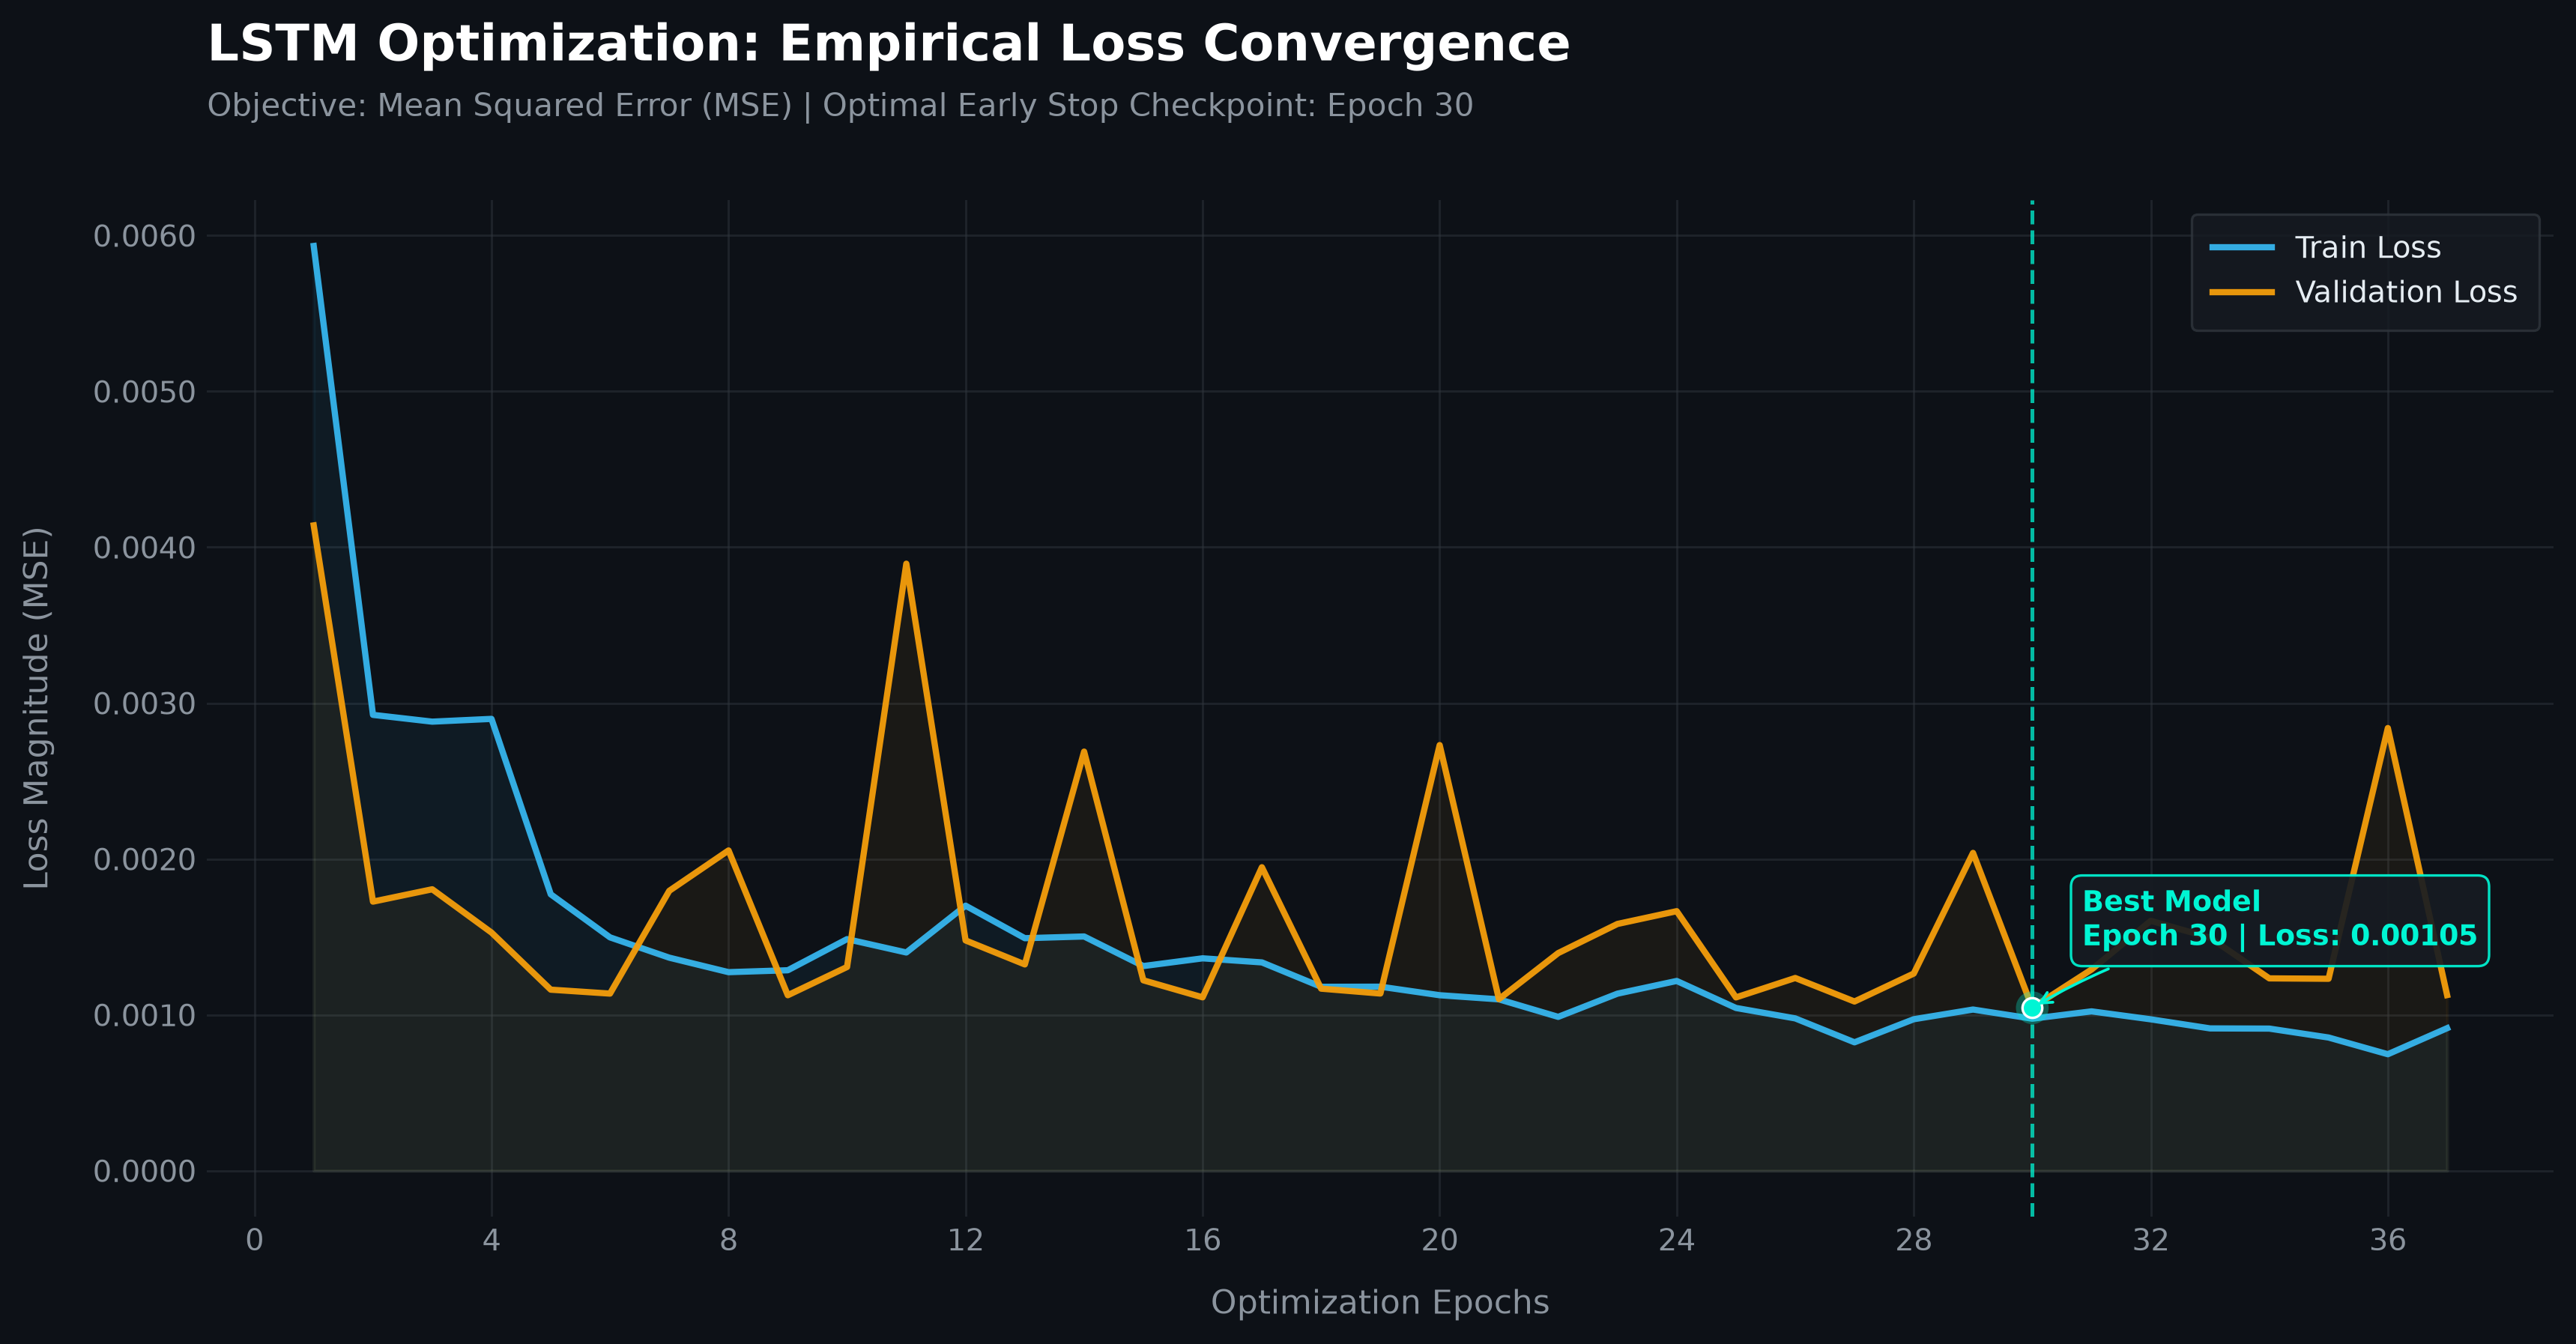

✔ Loss curve cleanly exported to: C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\results\deep_learning\lstm_loss_curve.png


In [37]:
# LSTM loss curve

from pathlib import Path
import matplotlib.ticker as ticker


DL_RESULTS_DIR = PROJECT_ROOT / "results" / "deep_learning"
DL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)


best_epoch = np.argmin(val_losses) + 1


plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(12, 6.2), dpi=300)
fig.patch.set_facecolor("#0D1117")
ax.set_facecolor("#0D1117")

# Epoch arrays
epochs_train = np.arange(1, len(train_losses) + 1)
epochs_val = np.arange(1, len(val_losses) + 1)

# Color Palette: Electric Sky Blue (Train) vs Vibrant Coral/Gold (Val)
train_color = "#38BDF8"
val_color = "#F59E0B"
best_epoch_color = "#00F5D4"

# 1. Plot Curves
ax.plot(
    epochs_train,
    train_losses,
    label="Train Loss",
    color=train_color,
    linewidth=2.0,
    alpha=0.9,
    zorder=3,)

ax.plot(
    epochs_val,
    val_losses,
    label="Validation Loss",
    color=val_color,
    linewidth=2.0,
    alpha=0.95,
    zorder=3,)

# 2. Ambient Shading Under Curves
ax.fill_between(epochs_train, train_losses, alpha=0.06, color=train_color, zorder=2)
ax.fill_between(epochs_val, val_losses, alpha=0.06, color=val_color, zorder=2)

# 3. Best Epoch Vertical Line & Focal Marker Pin
ax.axvline(
    best_epoch,
    color=best_epoch_color,
    linestyle="--",
    linewidth=1.2,
    alpha=0.75,
    zorder=4,)

# Best epoch minimum loss coordinate
best_val_loss = val_losses[best_epoch - 1]

# Halo glow + pinpoint marker
ax.scatter(
    [best_epoch],
    [best_val_loss],
    s=110,
    color=best_epoch_color,
    alpha=0.3,
    edgecolors="none",
    zorder=5,)
ax.scatter(
    [best_epoch],
    [best_val_loss],
    s=40,
    color=best_epoch_color,
    edgecolors="#FFFFFF",
    linewidths=0.8,
    zorder=6,)

# Metric Callout Badge for Best Epoch
ax.annotate(
    f"Best Model\nEpoch {best_epoch} | Loss: {best_val_loss:.5f}",
    xy=(best_epoch, best_val_loss),
    xytext=(16, 20),
    textcoords="offset points",
    fontsize=9,
    fontweight="bold",
    color=best_epoch_color,
    bbox=dict(
        boxstyle="round,pad=0.4",
        fc="#161B22",
        ec=best_epoch_color,
        lw=0.8,
        alpha=0.92,),
    arrowprops=dict(
        arrowstyle="->",
        color=best_epoch_color,
        lw=0.9,
        connectionstyle="arc3,rad=0.1",),
    zorder=7,)

# 4. Executive Left-Aligned Typography
fig.text(
    0.08,
    0.95,
    "LSTM Optimization: Empirical Loss Convergence",
    fontsize=16,
    fontweight="bold",
    color="#FFFFFF",
    ha="left",)
fig.text(
    0.08,
    0.91,
    f"Objective: Mean Squared Error (MSE) | Optimal Early Stop Checkpoint: Epoch {best_epoch}",
    fontsize=10,
    color="#8B949E",
    ha="left",)

# 5. Gridlines, Spines & Formatting
ax.grid(True, which="major", color="#30363D", linestyle="-", linewidth=0.7, alpha=0.5)
ax.grid(True, which="minor", color="#21262D", linestyle=":", linewidth=0.5, alpha=0.3)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

ax.tick_params(axis="both", which="both", colors="#8B949E", labelsize=9.5, length=0)
ax.set_xlabel("Optimization Epochs", color="#8B949E", fontsize=10.5, labelpad=10)
ax.set_ylabel("Loss Magnitude (MSE)", color="#8B949E", fontsize=10.5, labelpad=12)

# Optional Log-scale if loss drop is steep over orders of magnitude
if max(train_losses[0], val_losses[0]) / (min(train_losses[-1], val_losses[-1]) + 1e-8) > 100:
    ax.set_yscale("log")
else:
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.4f"))

ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=10))

# 6. Sleek Floating Legend
legend = ax.legend(
    loc="upper right",
    frameon=True,
    facecolor="#161B22",
    edgecolor="#30363D",
    fontsize=9.5,
    labelcolor="#E6EDF3",
    borderpad=0.7,)
legend.get_frame().set_linewidth(0.8)

# 7. Safe Path Handling & Ultra-HD Export
DL_RESULTS_DIR = Path(DL_RESULTS_DIR)
DL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
loss_curve_path = DL_RESULTS_DIR / "lstm_loss_curve.png"

plt.subplots_adjust(top=0.85, bottom=0.12, left=0.08, right=0.95)

plt.savefig(
    loss_curve_path,
    dpi=300,
    facecolor=fig.get_facecolor(),
    edgecolor="none",
    bbox_inches="tight",)
plt.show()
plt.close()

print(f"✔ Loss curve cleanly exported to: {loss_curve_path.resolve()}")

In [38]:
lstm_test_actual, lstm_test_pred = predict_model(
    lstm_model,
    test_loader,
    device)

lstm_metrics = calculate_regression_metrics(
    lstm_test_actual,
    lstm_test_pred)

print("LSTM — Held-Out Test Performance")
print("-" * 40)

for metric, value in lstm_metrics.items():
    print(f"{metric}: {value:.6f}")

LSTM — Held-Out Test Performance
----------------------------------------
RMSE: 0.040075
MAE: 0.030837
MAPE: 235.006470
R2: -0.049576
Directional_Accuracy: 56.571429


In [39]:
class GRURegressor(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size=64,
        num_layers=2,
        dropout=0.2
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0)

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(
            hidden_size,
            1)

    def forward(self, x):

        output, hidden = self.gru(x)

        # Last timestep
        last_output = output[:, -1, :]

        last_output = self.dropout(last_output)

        prediction = self.fc(last_output)

        return prediction


# Fresh GRU model
gru_model = GRURegressor(
    input_size=INPUT_SIZE,
    hidden_size=64,
    num_layers=2,
    dropout=0.2
).to(device)

print(gru_model)
print("\nDevice:", device)
print("Input features:", INPUT_SIZE)

GRURegressor(
  (gru): GRU(288, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Device: cpu
Input features: 288


In [41]:
# Sanity check before training

X_batch, y_batch = next(iter(train_loader))

X_batch = X_batch.to(device)
y_batch = y_batch.to(device)

with torch.no_grad():
    gru_output = gru_model(X_batch)

print("Input shape:", X_batch.shape)
print("Target shape:", y_batch.shape)
print("Output shape:", gru_output.shape)

print("\nInput contains NaN:",
      torch.isnan(X_batch).any().item())

print("Input contains Inf:",
      torch.isinf(X_batch).any().item())

print("Output contains NaN:",
      torch.isnan(gru_output).any().item())

print("Output contains Inf:",
      torch.isinf(gru_output).any().item())

print("\nSample predictions:")
print(gru_output[:5].cpu().numpy().flatten())

Input shape: torch.Size([32, 60, 288])
Target shape: torch.Size([32, 1])
Output shape: torch.Size([32, 1])

Input contains NaN: False
Input contains Inf: False
Output contains NaN: False
Output contains Inf: False

Sample predictions:
[0.12971148 0.13567644 0.20081192 0.48529986 0.35114375]


In [42]:
# GRU training configuration

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    gru_model.parameters(),
    lr=0.001,
    weight_decay=1e-5)

MAX_EPOCHS = 50
PATIENCE = 7

gru_train_losses = []
gru_val_losses = []

best_gru_val_loss = float("inf")
best_gru_model_state = None
gru_epochs_without_improvement = 0


for epoch in range(1, MAX_EPOCHS + 1):

    # Training
    gru_model.train()

    running_train_loss = 0.0
    train_samples = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = gru_model(X_batch)

        loss = criterion(
            predictions,
            y_batch)

        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            gru_model.parameters(),
            max_norm=1.0)

        optimizer.step()

        running_train_loss += (
            loss.item() * X_batch.size(0))

        train_samples += X_batch.size(0)


    epoch_train_loss = (
        running_train_loss / train_samples)


    # Validation
    gru_model.eval()

    running_val_loss = 0.0
    val_samples = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = gru_model(X_batch)

            loss = criterion(
                predictions,
                y_batch)

            running_val_loss += (
                loss.item() * X_batch.size(0))

            val_samples += X_batch.size(0)


    epoch_val_loss = (
        running_val_loss / val_samples)


    gru_train_losses.append(epoch_train_loss)
    gru_val_losses.append(epoch_val_loss)


    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {epoch_train_loss:.6f} | "
        f"Val Loss: {epoch_val_loss:.6f}")

    # Best model + early stopping
    if epoch_val_loss < best_gru_val_loss:

        best_gru_val_loss = epoch_val_loss

        best_gru_model_state = copy.deepcopy(
            gru_model.state_dict())

        gru_epochs_without_improvement = 0

    else:

        gru_epochs_without_improvement += 1

        if gru_epochs_without_improvement >= PATIENCE:

            print(
                f"\nEarly stopping triggered "
                f"at epoch {epoch}")

            break


# Restore best GRU checkpoint
if best_gru_model_state is not None:

    gru_model.load_state_dict(
        best_gru_model_state)

    print(
        "\nBest GRU validation loss:",
        best_gru_val_loss)

    print("Best GRU model restored.")

else:

    raise RuntimeError(
        "No valid GRU checkpoint was created.")

Epoch 01 | Train Loss: 0.024314 | Val Loss: 0.003371
Epoch 02 | Train Loss: 0.009714 | Val Loss: 0.001919
Epoch 03 | Train Loss: 0.008026 | Val Loss: 0.010372
Epoch 04 | Train Loss: 0.005770 | Val Loss: 0.001585
Epoch 05 | Train Loss: 0.003901 | Val Loss: 0.001234
Epoch 06 | Train Loss: 0.003229 | Val Loss: 0.001329
Epoch 07 | Train Loss: 0.002623 | Val Loss: 0.001356
Epoch 08 | Train Loss: 0.002336 | Val Loss: 0.002748
Epoch 09 | Train Loss: 0.002030 | Val Loss: 0.001272
Epoch 10 | Train Loss: 0.001852 | Val Loss: 0.001172
Epoch 11 | Train Loss: 0.001649 | Val Loss: 0.001237
Epoch 12 | Train Loss: 0.001603 | Val Loss: 0.001286
Epoch 13 | Train Loss: 0.001428 | Val Loss: 0.001476
Epoch 14 | Train Loss: 0.001385 | Val Loss: 0.001243
Epoch 15 | Train Loss: 0.001342 | Val Loss: 0.001234
Epoch 16 | Train Loss: 0.001258 | Val Loss: 0.001607
Epoch 17 | Train Loss: 0.001333 | Val Loss: 0.002087

Early stopping triggered at epoch 17

Best GRU validation loss: 0.0011724427891229945
Best GRU mod

In [43]:
# GRU Held-Out Test Performance

gru_test_actual, gru_test_pred = predict_model(
    gru_model,
    test_loader,
    device)


gru_metrics = calculate_regression_metrics(
    gru_test_actual,
    gru_test_pred)


print("GRU — Held-Out Test Performance")
print()


for metric, value in gru_metrics.items():
    print(f"{metric}: {value:.6f}")

GRU — Held-Out Test Performance

RMSE: 0.041826
MAE: 0.032561
MAPE: 191.337952
R2: -0.143343
Directional_Accuracy: 44.571429


In [44]:
print("Actual returns:")
print(gru_test_actual[:10])

print("\nPredicted returns:")
print(gru_test_pred[:10])

print("\nPrediction range:")
print("Min:", gru_test_pred.min())
print("Max:", gru_test_pred.max())
print("Mean:", gru_test_pred.mean())

Actual returns:
[ 0.17236981 -0.02303245  0.03445015 -0.02518289 -0.01372703  0.01216982
  0.07257935  0.06244291  0.08790638  0.05742466]

Predicted returns:
[ 0.00166641 -0.00229203 -0.01454383  0.00169464 -0.00428786 -0.00268912
 -0.00050753 -0.00124539 -0.00664392 -0.00315542]

Prediction range:
Min: -0.020630578
Max: 0.011151332
Mean: -0.0058729425


In [45]:
print("GRU — Held-Out Test Performance")
print()

for metric, value in gru_metrics.items():
    print(f"{metric}: {value:.6f}")

GRU — Held-Out Test Performance

RMSE: 0.041826
MAE: 0.032561
MAPE: 191.337952
R2: -0.143343
Directional_Accuracy: 44.571429


In [46]:
# BiLSTM architecture

class BiLSTMRegressor(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size=32,
        num_layers=2,
        dropout=0.2):
        super().__init__()


        self.bilstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0)


        self.dropout = nn.Dropout(dropout)


        # Bidirectional = hidden_size * 2
        self.fc = nn.Linear(
            hidden_size * 2,
            1)


    def forward(self, x):


        output, (hidden, cell) = self.bilstm(x)


        # Last timestep
        last_output = output[:, -1, :]


        last_output = self.dropout(last_output)


        prediction = self.fc(last_output)


        return prediction




bilstm_model = BiLSTMRegressor(
    input_size=INPUT_SIZE,
    hidden_size=32,
    num_layers=2,
    dropout=0.2
).to(device)


print(bilstm_model)
print("\nDevice:", device)
print("Input features:", INPUT_SIZE)

BiLSTMRegressor(
  (bilstm): LSTM(288, 32, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Device: cpu
Input features: 288


In [47]:
# Sanity check

X_batch, y_batch = next(iter(train_loader))


X_batch = X_batch.to(device)
y_batch = y_batch.to(device)


with torch.no_grad():
    bilstm_output = bilstm_model(X_batch)


print("Input shape:", X_batch.shape)
print("Target shape:", y_batch.shape)
print("Output shape:", bilstm_output.shape)


print("\nInput contains NaN:",
      torch.isnan(X_batch).any().item())


print("Input contains Inf:",
      torch.isinf(X_batch).any().item())


print("Output contains NaN:",
      torch.isnan(bilstm_output).any().item())


print("Output contains Inf:",
      torch.isinf(bilstm_output).any().item())


print("\nSample predictions:")
print(bilstm_output[:5].cpu().numpy().flatten())

Input shape: torch.Size([32, 60, 288])
Target shape: torch.Size([32, 1])
Output shape: torch.Size([32, 1])

Input contains NaN: False
Input contains Inf: False
Output contains NaN: False
Output contains Inf: False

Sample predictions:
[0.16828074 0.14236504 0.08409663 0.10574187 0.13468815]


In [48]:
# BiLSTM training configuration

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    bilstm_model.parameters(),
    lr=0.001,
    weight_decay=1e-5)

MAX_EPOCHS = 50
PATIENCE = 7

bilstm_train_losses = []
bilstm_val_losses = []

best_bilstm_val_loss = float("inf")
best_bilstm_model_state = None
bilstm_epochs_without_improvement = 0


for epoch in range(1, MAX_EPOCHS + 1):

    # Training
    bilstm_model.train()

    running_train_loss = 0.0
    train_samples = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = bilstm_model(X_batch)

        loss = criterion(
            predictions,
            y_batch)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            bilstm_model.parameters(),
            max_norm=1.0)

        optimizer.step()

        running_train_loss += (
            loss.item() * X_batch.size(0))

        train_samples += X_batch.size(0)


    epoch_train_loss = (
        running_train_loss / train_samples)

    # Validation
    bilstm_model.eval()

    running_val_loss = 0.0
    val_samples = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = bilstm_model(X_batch)

            loss = criterion(
                predictions,
                y_batch)

            running_val_loss += (
                loss.item() * X_batch.size(0))

            val_samples += X_batch.size(0)


    epoch_val_loss = (
        running_val_loss / val_samples)


    bilstm_train_losses.append(epoch_train_loss)
    bilstm_val_losses.append(epoch_val_loss)


    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {epoch_train_loss:.6f} | "
        f"Val Loss: {epoch_val_loss:.6f}")

    # Best checkpoint
    if epoch_val_loss < best_bilstm_val_loss:

        best_bilstm_val_loss = epoch_val_loss

        best_bilstm_model_state = copy.deepcopy(
            bilstm_model.state_dict())

        bilstm_epochs_without_improvement = 0

    else:

        bilstm_epochs_without_improvement += 1

        if bilstm_epochs_without_improvement >= PATIENCE:

            print(
                f"\nEarly stopping triggered "
                f"at epoch {epoch}")

            break

# Restore best checkpoint

if best_bilstm_model_state is not None:

    bilstm_model.load_state_dict(
        best_bilstm_model_state)

    print(
        "\nBest BiLSTM validation loss:",
        best_bilstm_val_loss)

    print("Best BiLSTM model restored.")

else:

    raise RuntimeError(
        "No valid BiLSTM checkpoint was created.")

Epoch 01 | Train Loss: 0.004163 | Val Loss: 0.003247
Epoch 02 | Train Loss: 0.002884 | Val Loss: 0.005757
Epoch 03 | Train Loss: 0.002584 | Val Loss: 0.001321
Epoch 04 | Train Loss: 0.001958 | Val Loss: 0.001175
Epoch 05 | Train Loss: 0.001664 | Val Loss: 0.001387
Epoch 06 | Train Loss: 0.001392 | Val Loss: 0.001324
Epoch 07 | Train Loss: 0.001489 | Val Loss: 0.002275
Epoch 08 | Train Loss: 0.001390 | Val Loss: 0.001152
Epoch 09 | Train Loss: 0.001528 | Val Loss: 0.002140
Epoch 10 | Train Loss: 0.001395 | Val Loss: 0.001527
Epoch 11 | Train Loss: 0.001484 | Val Loss: 0.001168
Epoch 12 | Train Loss: 0.001268 | Val Loss: 0.001221
Epoch 13 | Train Loss: 0.001176 | Val Loss: 0.001818
Epoch 14 | Train Loss: 0.001203 | Val Loss: 0.001144
Epoch 15 | Train Loss: 0.001368 | Val Loss: 0.001956
Epoch 16 | Train Loss: 0.001307 | Val Loss: 0.002340
Epoch 17 | Train Loss: 0.001166 | Val Loss: 0.001361
Epoch 18 | Train Loss: 0.001086 | Val Loss: 0.001457
Epoch 19 | Train Loss: 0.001097 | Val Loss: 0.

In [49]:
bilstm_test_actual, bilstm_test_pred = predict_model(
    bilstm_model,
    test_loader,
    device
)

bilstm_metrics = calculate_regression_metrics(
    bilstm_test_actual,
    bilstm_test_pred
)

print("BiLSTM — Held-Out Test Performance")
print("-" * 40)

for metric, value in bilstm_metrics.items():
    print(f"{metric}: {value:.6f}")

BiLSTM — Held-Out Test Performance
----------------------------------------
RMSE: 0.044253
MAE: 0.034957
MAPE: 212.305115
R2: -0.279829
Directional_Accuracy: 44.857143


In [50]:
print("Actual returns:")
print(bilstm_test_actual[:10])

print("\nPredicted returns:")
print(bilstm_test_pred[:10])

print("\nPrediction range:")
print("Min:", bilstm_test_pred.min())
print("Max:", bilstm_test_pred.max())
print("Mean:", bilstm_test_pred.mean())

Actual returns:
[ 0.17236981 -0.02303245  0.03445015 -0.02518289 -0.01372703  0.01216982
  0.07257935  0.06244291  0.08790638  0.05742466]

Predicted returns:
[ 0.01108739  0.01443549  0.01830313  0.00898119 -0.00093081 -0.00435396
 -0.00493117 -0.00869958 -0.00607873 -0.00927671]

Prediction range:
Min: -0.027301418
Max: 0.018303128
Mean: -0.011755797


In [51]:
class TransformerRegressor(nn.Module):
    def __init__(
        self,
        input_size,
        d_model=64,
        nhead=4,
        num_layers=2,
        dropout=0.2
    ):
        super().__init__()

        self.input_projection = nn.Linear(
            input_size,
            d_model)

        self.position_embedding = nn.Parameter(
            torch.zeros(1, SEQUENCE_LENGTH, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True,
            activation="gelu")

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers)

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(
            d_model,
            1)

    def forward(self, x):

        x = self.input_projection(x)

        x = x + self.position_embedding[:, :x.size(1), :]

        x = self.transformer(x)

        x = x[:, -1, :]

        x = self.dropout(x)

        prediction = self.fc(x)

        return prediction


transformer_model = TransformerRegressor(
    input_size=INPUT_SIZE,
    d_model=64,
    nhead=4,
    num_layers=2,
    dropout=0.2
).to(device)

print(transformer_model)
print("\nDevice:", device)
print("Input features:", INPUT_SIZE)
print("Sequence length:", SEQUENCE_LENGTH)

TransformerRegressor(
  (input_projection): Linear(in_features=288, out_features=64, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Device: cpu
Input features: 288
Sequence length: 60


In [52]:
X_batch, y_batch = next(iter(train_loader))

X_batch = X_batch.to(device)
y_batch = y_batch.to(device)

with torch.no_grad():
    transformer_output = transformer_model(X_batch)

print("Input shape:", X_batch.shape)
print("Target shape:", y_batch.shape)
print("Output shape:", transformer_output.shape)

print("\nInput contains NaN:",
      torch.isnan(X_batch).any().item())

print("Input contains Inf:",
      torch.isinf(X_batch).any().item())

print("Output contains NaN:",
      torch.isnan(transformer_output).any().item())

print("Output contains Inf:",
      torch.isinf(transformer_output).any().item())

print("\nSample predictions:")
print(transformer_output[:5].cpu().numpy().flatten())

Input shape: torch.Size([32, 60, 288])
Target shape: torch.Size([32, 1])
Output shape: torch.Size([32, 1])

Input contains NaN: False
Input contains Inf: False
Output contains NaN: False
Output contains Inf: False

Sample predictions:
[2.1905148 1.0972345 1.3916128 1.3631606 1.3397727]


In [53]:
# Transformer training configuration

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    transformer_model.parameters(),
    lr=0.001,
    weight_decay=1e-5)

MAX_EPOCHS = 50
PATIENCE = 7

transformer_train_losses = []
transformer_val_losses = []

best_transformer_val_loss = float("inf")
best_transformer_model_state = None
transformer_epochs_without_improvement = 0


for epoch in range(1, MAX_EPOCHS + 1):

    # Training
    transformer_model.train()

    running_train_loss = 0.0
    train_samples = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = transformer_model(X_batch)

        loss = criterion(
            predictions,
            y_batch)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            transformer_model.parameters(),
            max_norm=1.0)

        optimizer.step()

        running_train_loss += (
            loss.item() * X_batch.size(0))

        train_samples += X_batch.size(0)


    epoch_train_loss = (
        running_train_loss / train_samples)

    # Validation
    transformer_model.eval()

    running_val_loss = 0.0
    val_samples = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = transformer_model(X_batch)

            loss = criterion(
                predictions,
                y_batch)

            running_val_loss += (
                loss.item() * X_batch.size(0))

            val_samples += X_batch.size(0)


    epoch_val_loss = (
        running_val_loss / val_samples)


    transformer_train_losses.append(
        epoch_train_loss)

    transformer_val_losses.append(
        epoch_val_loss)


    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {epoch_train_loss:.6f} | "
        f"Val Loss: {epoch_val_loss:.6f}")

    # Best checkpoint
    if epoch_val_loss < best_transformer_val_loss:

        best_transformer_val_loss = epoch_val_loss

        best_transformer_model_state = copy.deepcopy(
            transformer_model.state_dict())

        transformer_epochs_without_improvement = 0

    else:

        transformer_epochs_without_improvement += 1

        if transformer_epochs_without_improvement >= PATIENCE:

            print(
                f"\nEarly stopping triggered "
                f"at epoch {epoch}"
            )

            break
# Restore best checkpoint

if best_transformer_model_state is not None:

    transformer_model.load_state_dict(
        best_transformer_model_state)

    print(
        "\nBest Transformer validation loss:",
        best_transformer_val_loss)

    print("Best Transformer model restored.")

else:

    raise RuntimeError(
        "No valid Transformer checkpoint was created.")

Epoch 01 | Train Loss: 0.103419 | Val Loss: 0.003313
Epoch 02 | Train Loss: 0.007849 | Val Loss: 0.001966
Epoch 03 | Train Loss: 0.004078 | Val Loss: 0.004381
Epoch 04 | Train Loss: 0.005771 | Val Loss: 0.001239
Epoch 05 | Train Loss: 0.003952 | Val Loss: 0.002334
Epoch 06 | Train Loss: 0.006475 | Val Loss: 0.001813
Epoch 07 | Train Loss: 0.003860 | Val Loss: 0.001305
Epoch 08 | Train Loss: 0.002146 | Val Loss: 0.001069
Epoch 09 | Train Loss: 0.002039 | Val Loss: 0.001063
Epoch 10 | Train Loss: 0.001893 | Val Loss: 0.001051
Epoch 11 | Train Loss: 0.001961 | Val Loss: 0.001047
Epoch 12 | Train Loss: 0.002005 | Val Loss: 0.001050
Epoch 13 | Train Loss: 0.002110 | Val Loss: 0.001085
Epoch 14 | Train Loss: 0.001962 | Val Loss: 0.001048
Epoch 15 | Train Loss: 0.001719 | Val Loss: 0.001046
Epoch 16 | Train Loss: 0.001737 | Val Loss: 0.001067
Epoch 17 | Train Loss: 0.001638 | Val Loss: 0.001049
Epoch 18 | Train Loss: 0.001577 | Val Loss: 0.001052
Epoch 19 | Train Loss: 0.001613 | Val Loss: 0.

In [54]:
transformer_test_actual, transformer_test_pred = predict_model(
    transformer_model,
    test_loader,
    device
)

transformer_metrics = calculate_regression_metrics(
    transformer_test_actual,
    transformer_test_pred
)

print("Transformer — Held-Out Test Performance")
print("-" * 40)

for metric, value in transformer_metrics.items():
    print(f"{metric}: {value:.6f}")

Transformer — Held-Out Test Performance
----------------------------------------
RMSE: 0.039660
MAE: 0.030758
MAPE: 115.646919
R2: -0.027989
Directional_Accuracy: 58.000000


In [55]:
print("Actual returns:")
print(transformer_test_actual[:10])

print("\nPredicted returns:")
print(transformer_test_pred[:10])

print("\nPrediction range:")
print("Min:", transformer_test_pred.min())
print("Max:", transformer_test_pred.max())
print("Mean:", transformer_test_pred.mean())

Actual returns:
[ 0.17236981 -0.02303245  0.03445015 -0.02518289 -0.01372703  0.01216982
  0.07257935  0.06244291  0.08790638  0.05742466]

Predicted returns:
[0.00465473 0.00451289 0.00196239 0.00339036 0.00217233 0.0018381
 0.00208584 0.00256794 0.00173756 0.00261497]

Prediction range:
Min: -0.00020067766
Max: 0.004654728
Mean: 0.0014448744


In [56]:
# LSTM-Small Architecture

class LSTMSmallRegressor(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size=32,
        dropout=0.2
    ):
        super().__init__()


        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True)


        self.dropout = nn.Dropout(dropout)


        self.fc = nn.Linear(
            hidden_size,
            1)


    def forward(self, x):


        output, (hidden, cell) = self.lstm(x)


        # Last timestep
        last_output = output[:, -1, :]


        last_output = self.dropout(last_output)


        prediction = self.fc(last_output)


        return prediction




lstm_small_model = LSTMSmallRegressor(
    input_size=INPUT_SIZE,
    hidden_size=32,
    dropout=0.2
).to(device)


print(lstm_small_model)
print("\nDevice:", device)
print("Input features:", INPUT_SIZE)
print("Sequence length:", SEQUENCE_LENGTH)

LSTMSmallRegressor(
  (lstm): LSTM(288, 32, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

Device: cpu
Input features: 288
Sequence length: 60


In [57]:
# Sanity Check

X_batch, y_batch = next(iter(train_loader))


X_batch = X_batch.to(device)
y_batch = y_batch.to(device)


with torch.no_grad():
    lstm_small_output = lstm_small_model(X_batch)


print("Input shape:", X_batch.shape)
print("Target shape:", y_batch.shape)
print("Output shape:", lstm_small_output.shape)


print("\nInput contains NaN:",
      torch.isnan(X_batch).any().item())


print("Input contains Inf:",
      torch.isinf(X_batch).any().item())


print("Output contains NaN:",
      torch.isnan(lstm_small_output).any().item())


print("Output contains Inf:",
      torch.isinf(lstm_small_output).any().item())


print("\nSample predictions:")
print(
    lstm_small_output[:5]
    .cpu()
    .numpy()
    .flatten())

Input shape: torch.Size([32, 60, 288])
Target shape: torch.Size([32, 1])
Output shape: torch.Size([32, 1])

Input contains NaN: False
Input contains Inf: False
Output contains NaN: False
Output contains Inf: False

Sample predictions:
[-0.2584526   0.08223855  0.00600593  0.14950469  0.25441286]


In [59]:
# LSTM-Small training configuration

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    lstm_small_model.parameters(),
    lr=0.001,
    weight_decay=1e-5)

MAX_EPOCHS = 50
PATIENCE = 7

lstm_small_train_losses = []
lstm_small_val_losses = []

best_lstm_small_val_loss = float("inf")
best_lstm_small_model_state = None
lstm_small_epochs_without_improvement = 0


for epoch in range(1, MAX_EPOCHS + 1):

    # Training
    lstm_small_model.train()

    running_train_loss = 0.0
    train_samples = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = lstm_small_model(X_batch)

        loss = criterion(
            predictions,
            y_batch)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            lstm_small_model.parameters(),
            max_norm=1.0)

        optimizer.step()

        running_train_loss += (
            loss.item() * X_batch.size(0))

        train_samples += X_batch.size(0)


    epoch_train_loss = (
        running_train_loss / train_samples)

    # Validation
    lstm_small_model.eval()

    running_val_loss = 0.0
    val_samples = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = lstm_small_model(X_batch)

            loss = criterion(
                predictions,
                y_batch)

            running_val_loss += (
                loss.item() * X_batch.size(0))

            val_samples += X_batch.size(0)


    epoch_val_loss = (
        running_val_loss / val_samples)


    lstm_small_train_losses.append(epoch_train_loss)
    lstm_small_val_losses.append(epoch_val_loss)


    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {epoch_train_loss:.6f} | "
        f"Val Loss: {epoch_val_loss:.6f}")

    # Best checkpoint
    if epoch_val_loss < best_lstm_small_val_loss:

        best_lstm_small_val_loss = epoch_val_loss

        best_lstm_small_model_state = copy.deepcopy(
            lstm_small_model.state_dict())

        lstm_small_epochs_without_improvement = 0

    else:

        lstm_small_epochs_without_improvement += 1

        if lstm_small_epochs_without_improvement >= PATIENCE:

            print(
                f"\nEarly stopping triggered "
                f"at epoch {epoch}")
            break

# Restore best checkpoint

if best_lstm_small_model_state is not None:

    lstm_small_model.load_state_dict(
        best_lstm_small_model_state)

    print(
        "\nBest LSTM-Small validation loss:",
        best_lstm_small_val_loss)

    print("Best LSTM-Small model restored.")

else:

    raise RuntimeError(
        "No valid LSTM-Small checkpoint was created.")

Epoch 01 | Train Loss: 0.045703 | Val Loss: 0.032398
Epoch 02 | Train Loss: 0.038083 | Val Loss: 0.018923
Epoch 03 | Train Loss: 0.020349 | Val Loss: 0.079614
Epoch 04 | Train Loss: 0.025688 | Val Loss: 0.003093
Epoch 05 | Train Loss: 0.008021 | Val Loss: 0.005892
Epoch 06 | Train Loss: 0.003938 | Val Loss: 0.006049
Epoch 07 | Train Loss: 0.003606 | Val Loss: 0.004627
Epoch 08 | Train Loss: 0.002831 | Val Loss: 0.004304
Epoch 09 | Train Loss: 0.002586 | Val Loss: 0.003735
Epoch 10 | Train Loss: 0.002293 | Val Loss: 0.003170
Epoch 11 | Train Loss: 0.001975 | Val Loss: 0.002907
Epoch 12 | Train Loss: 0.001825 | Val Loss: 0.002430
Epoch 13 | Train Loss: 0.001748 | Val Loss: 0.002001
Epoch 14 | Train Loss: 0.001708 | Val Loss: 0.001807
Epoch 15 | Train Loss: 0.001510 | Val Loss: 0.001739
Epoch 16 | Train Loss: 0.001415 | Val Loss: 0.001519
Epoch 17 | Train Loss: 0.001363 | Val Loss: 0.001469
Epoch 18 | Train Loss: 0.001285 | Val Loss: 0.001357
Epoch 19 | Train Loss: 0.001233 | Val Loss: 0.

In [60]:
# LSTM-Small Test Metrics

lstm_small_test_actual, lstm_small_test_pred = predict_model(
    lstm_small_model,
    test_loader,
    device)


lstm_small_metrics = calculate_regression_metrics(
    lstm_small_test_actual,
    lstm_small_test_pred)


print("LSTM-Small — Held-Out Test Performance")
print()


for metric, value in lstm_small_metrics.items():
    print(f"{metric}: {value:.6f}")

LSTM-Small — Held-Out Test Performance

RMSE: 0.042104
MAE: 0.033306
MAPE: 271.829407
R2: -0.158555
Directional_Accuracy: 52.571429


In [61]:
print("Actual returns:")
print(lstm_small_test_actual[:10])

print("\nPredicted returns:")
print(lstm_small_test_pred[:10])

print("\nPrediction range:")
print("Min:", lstm_small_test_pred.min())
print("Max:", lstm_small_test_pred.max())
print("Mean:", lstm_small_test_pred.mean())

Actual returns:
[ 0.17236981 -0.02303245  0.03445015 -0.02518289 -0.01372703  0.01216982
  0.07257935  0.06244291  0.08790638  0.05742466]

Predicted returns:
[0.05558572 0.0536226  0.02820246 0.04852036 0.03524334 0.03274454
 0.03976195 0.03187726 0.02333852 0.02993515]

Prediction range:
Min: -0.045102283
Max: 0.05558572
Mean: 0.008683928


In [67]:
# GRU-Small 
class GRUSmallRegressor(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size=32,
        dropout=0.2):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True)

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(
            hidden_size,
            1)

    def forward(self, x):

        output, hidden = self.gru(x)

        # Last timestep
        last_output = output[:, -1, :]

        last_output = self.dropout(last_output)

        prediction = self.fc(last_output)

        return prediction


gru_small_model = GRUSmallRegressor(
    input_size=INPUT_SIZE,
    hidden_size=32,
    dropout=0.2
).to(device)

print(gru_small_model)
print("\nDevice:", device)
print("Input features:", INPUT_SIZE)
print("Sequence length:", SEQUENCE_LENGTH)

GRUSmallRegressor(
  (gru): GRU(288, 32, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

Device: cpu
Input features: 288
Sequence length: 60


In [68]:
# Sanity check

X_batch, y_batch = next(iter(train_loader))


X_batch = X_batch.to(device)
y_batch = y_batch.to(device)


with torch.no_grad():
    gru_small_output = gru_small_model(X_batch)


print("Input shape:", X_batch.shape)
print("Target shape:", y_batch.shape)
print("Output shape:", gru_small_output.shape)


print("\nInput contains NaN:",
      torch.isnan(X_batch).any().item())


print("Input contains Inf:",
      torch.isinf(X_batch).any().item())


print("Output contains NaN:",
      torch.isnan(gru_small_output).any().item())


print("Output contains Inf:",
      torch.isinf(gru_small_output).any().item())


print("\nSample predictions:")
print(
    gru_small_output[:5]
    .cpu()
    .numpy()
    .flatten())

Input shape: torch.Size([32, 60, 288])
Target shape: torch.Size([32, 1])
Output shape: torch.Size([32, 1])

Input contains NaN: False
Input contains Inf: False
Output contains NaN: False
Output contains Inf: False

Sample predictions:
[ 0.36290532 -0.2434099   0.18748948 -0.17740351  0.33798745]


In [69]:
# GRU-Small training configuration

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    gru_small_model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

MAX_EPOCHS = 50
PATIENCE = 7

gru_small_train_losses = []
gru_small_val_losses = []

best_gru_small_val_loss = float("inf")
best_gru_small_model_state = None
gru_small_epochs_without_improvement = 0


for epoch in range(1, MAX_EPOCHS + 1):

    # =========================
    # Training
    # =========================
    gru_small_model.train()

    running_train_loss = 0.0
    train_samples = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = gru_small_model(X_batch)

        loss = criterion(
            predictions,
            y_batch
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            gru_small_model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        running_train_loss += (
            loss.item() * X_batch.size(0)
        )

        train_samples += X_batch.size(0)


    epoch_train_loss = (
        running_train_loss / train_samples
    )


    # =========================
    # Validation
    # =========================
    gru_small_model.eval()

    running_val_loss = 0.0
    val_samples = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = gru_small_model(X_batch)

            loss = criterion(
                predictions,
                y_batch
            )

            running_val_loss += (
                loss.item() * X_batch.size(0)
            )

            val_samples += X_batch.size(0)


    epoch_val_loss = (
        running_val_loss / val_samples
    )


    gru_small_train_losses.append(epoch_train_loss)
    gru_small_val_losses.append(epoch_val_loss)


    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {epoch_train_loss:.6f} | "
        f"Val Loss: {epoch_val_loss:.6f}"
    )


    # =========================
    # Best checkpoint
    # =========================
    if epoch_val_loss < best_gru_small_val_loss:

        best_gru_small_val_loss = epoch_val_loss

        best_gru_small_model_state = copy.deepcopy(
            gru_small_model.state_dict()
        )

        gru_small_epochs_without_improvement = 0

    else:

        gru_small_epochs_without_improvement += 1

        if gru_small_epochs_without_improvement >= PATIENCE:

            print(
                f"\nEarly stopping triggered "
                f"at epoch {epoch}"
            )

            break


# =========================
# Restore best checkpoint
# =========================

if best_gru_small_model_state is not None:

    gru_small_model.load_state_dict(
        best_gru_small_model_state
    )

    print(
        "\nBest GRU-Small validation loss:",
        best_gru_small_val_loss
    )

    print("Best GRU-Small model restored.")

else:

    raise RuntimeError(
        "No valid GRU-Small checkpoint was created."
    )

Epoch 01 | Train Loss: 0.095759 | Val Loss: 0.029262
Epoch 02 | Train Loss: 0.050604 | Val Loss: 0.040474
Epoch 03 | Train Loss: 0.046400 | Val Loss: 0.040245
Epoch 04 | Train Loss: 0.042106 | Val Loss: 0.089555
Epoch 05 | Train Loss: 0.014864 | Val Loss: 0.010578
Epoch 06 | Train Loss: 0.009790 | Val Loss: 0.004750
Epoch 07 | Train Loss: 0.006436 | Val Loss: 0.009825
Epoch 08 | Train Loss: 0.004152 | Val Loss: 0.005911
Epoch 09 | Train Loss: 0.003014 | Val Loss: 0.004728
Epoch 10 | Train Loss: 0.002368 | Val Loss: 0.003132
Epoch 11 | Train Loss: 0.001995 | Val Loss: 0.003219
Epoch 12 | Train Loss: 0.001720 | Val Loss: 0.003400
Epoch 13 | Train Loss: 0.001628 | Val Loss: 0.002681
Epoch 14 | Train Loss: 0.001517 | Val Loss: 0.002131
Epoch 15 | Train Loss: 0.001468 | Val Loss: 0.001965
Epoch 16 | Train Loss: 0.001409 | Val Loss: 0.001751
Epoch 17 | Train Loss: 0.001396 | Val Loss: 0.001679
Epoch 18 | Train Loss: 0.001346 | Val Loss: 0.001554
Epoch 19 | Train Loss: 0.001355 | Val Loss: 0.

In [70]:
# GRU-Small Test Metrics
gru_small_test_actual, gru_small_test_pred = predict_model(
    gru_small_model,
    test_loader,
    device)


gru_small_metrics = calculate_regression_metrics(
    gru_small_test_actual,
    gru_small_test_pred)


print("GRU-Small — Held-Out Test Performance")
print()


for metric, value in gru_small_metrics.items():
    print(f"{metric}: {value:.6f}")

GRU-Small — Held-Out Test Performance

RMSE: 0.040958
MAE: 0.031973
MAPE: 324.799927
R2: -0.096360
Directional_Accuracy: 57.142857


In [71]:
print("Actual returns:")
print(gru_small_test_actual[:10])

print("\nPredicted returns:")
print(gru_small_test_pred[:10])

print("\nPrediction range:")
print("Min:", gru_small_test_pred.min())
print("Max:", gru_small_test_pred.max())
print("Mean:", gru_small_test_pred.mean())

Actual returns:
[ 0.17236981 -0.02303245  0.03445015 -0.02518289 -0.01372703  0.01216982
  0.07257935  0.06244291  0.08790638  0.05742466]

Predicted returns:
[0.02288874 0.01715766 0.00084221 0.01450048 0.00193287 0.00934948
 0.0174155  0.02204011 0.01727142 0.02454815]

Prediction range:
Min: 0.00084221177
Max: 0.036180876
Mean: 0.017816197


In [72]:
# BiLSTM-Small

class BiLSTMSmallRegressor(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size=16,
        dropout=0.2):
        super().__init__()

        self.bilstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True)

        self.dropout = nn.Dropout(dropout)

        # Bidirectional output = hidden_size * 2
        self.fc = nn.Linear(
            hidden_size * 2,
            1)

    def forward(self, x):

        output, (hidden, cell) = self.bilstm(x)

        last_output = output[:, -1, :]

        last_output = self.dropout(last_output)

        prediction = self.fc(last_output)

        return prediction


bilstm_small_model = BiLSTMSmallRegressor(
    input_size=INPUT_SIZE,
    hidden_size=16,
    dropout=0.2
).to(device)

print(bilstm_small_model)
print("\nDevice:", device)
print("Input features:", INPUT_SIZE)
print("Sequence length:", SEQUENCE_LENGTH)

BiLSTMSmallRegressor(
  (bilstm): LSTM(288, 16, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

Device: cpu
Input features: 288
Sequence length: 60


In [73]:
# Sanity check

X_batch, y_batch = next(iter(train_loader))


X_batch = X_batch.to(device)
y_batch = y_batch.to(device)


with torch.no_grad():
    bilstm_small_output = bilstm_small_model(X_batch)


print("Input shape:", X_batch.shape)
print("Target shape:", y_batch.shape)
print("Output shape:", bilstm_small_output.shape)


print("\nInput contains NaN:",
      torch.isnan(X_batch).any().item())


print("Input contains Inf:",
      torch.isinf(X_batch).any().item())


print("Output contains NaN:",
      torch.isnan(bilstm_small_output).any().item())


print("Output contains Inf:",
      torch.isinf(bilstm_small_output).any().item())


print("\nSample predictions:")
print(
    bilstm_small_output[:5]
    .cpu()
    .numpy()
    .flatten())

Input shape: torch.Size([32, 60, 288])
Target shape: torch.Size([32, 1])
Output shape: torch.Size([32, 1])

Input contains NaN: False
Input contains Inf: False
Output contains NaN: False
Output contains Inf: False

Sample predictions:
[ 0.23161802 -0.16731492 -0.06922343  0.06896603  0.05468015]


In [75]:
# Reproducibility / Seed Helper

import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

print("Seed set successfully.")

Seed set successfully.


In [78]:
# GENERIC DEEP LEARNING TRAINING FUNCTION
# ============================================================

import copy
import torch
import torch.nn as nn

def train_model(
    model,
    train_loader,
    val_loader,
    device,
    lr=0.001,
    weight_decay=1e-5,
    max_epochs=50,
    patience=7,
    grad_clip=1.0
):
    criterion = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())

    train_losses = []
    val_losses = []

    epochs_without_improvement = 0
    best_epoch = 0

    for epoch in range(1, max_epochs + 1):

        # -------------------------
        # Training
        # -------------------------
        model.train()
        train_loss = 0.0
        train_count = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)

            loss.backward()

            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=grad_clip
                )

            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)
            train_count += X_batch.size(0)

        train_loss /= train_count

        # -------------------------
        # Validation
        # -------------------------
        model.eval()
        val_loss = 0.0
        val_count = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                predictions = model(X_batch)
                loss = criterion(predictions, y_batch)

                val_loss += loss.item() * X_batch.size(0)
                val_count += X_batch.size(0)

        val_loss /= val_count

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # -------------------------
        # Best model checkpoint
        # -------------------------
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        print(
            f"Epoch {epoch:02d}/{max_epochs} | "
            f"Train Loss: {train_loss:.6f} | "
            f"Val Loss: {val_loss:.6f}"
        )

        # -------------------------
        # Early stopping
        # -------------------------
        if epochs_without_improvement >= patience:
            print(
                f"\nEarly stopping at epoch {epoch}. "
                f"Best epoch: {best_epoch} | "
                f"Best Val Loss: {best_val_loss:.6f}"
            )
            break

    # Restore best validation checkpoint
    model.load_state_dict(best_state)

    history = {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss
    }

    return model, history

In [79]:
# BiLSTM Small Training

set_seed(42)

bilstm_small_model = BiLSTMSmallRegressor(
    input_size=INPUT_SIZE,
    hidden_size=16,
    dropout=0.2
).to(device)

bilstm_small_model, bilstm_small_history = train_model(
    bilstm_small_model,
    train_loader,
    val_loader,
    device=device,
    lr=0.001,
    weight_decay=1e-5,
    max_epochs=50,
    patience=7,
    grad_clip=1.0)

Epoch 01/50 | Train Loss: 0.028475 | Val Loss: 0.020509
Epoch 02/50 | Train Loss: 0.014619 | Val Loss: 0.019397
Epoch 03/50 | Train Loss: 0.018988 | Val Loss: 0.003949
Epoch 04/50 | Train Loss: 0.009035 | Val Loss: 0.001820
Epoch 05/50 | Train Loss: 0.003377 | Val Loss: 0.002168
Epoch 06/50 | Train Loss: 0.002317 | Val Loss: 0.001642
Epoch 07/50 | Train Loss: 0.002080 | Val Loss: 0.001626
Epoch 08/50 | Train Loss: 0.001884 | Val Loss: 0.001601
Epoch 09/50 | Train Loss: 0.001726 | Val Loss: 0.001542
Epoch 10/50 | Train Loss: 0.001478 | Val Loss: 0.001477
Epoch 11/50 | Train Loss: 0.001382 | Val Loss: 0.001446
Epoch 12/50 | Train Loss: 0.001399 | Val Loss: 0.001441
Epoch 13/50 | Train Loss: 0.001308 | Val Loss: 0.001447
Epoch 14/50 | Train Loss: 0.001207 | Val Loss: 0.001432
Epoch 15/50 | Train Loss: 0.001211 | Val Loss: 0.001380
Epoch 16/50 | Train Loss: 0.001116 | Val Loss: 0.001348
Epoch 17/50 | Train Loss: 0.001065 | Val Loss: 0.001342
Epoch 18/50 | Train Loss: 0.001014 | Val Loss: 0

In [80]:
#  BiLSTM Small Test Evaluation

bilstm_small_model.eval()

y_test_actual, y_test_pred = predict_model(
    bilstm_small_model,
    test_loader,
    device)

bilstm_small_metrics = calculate_regression_metrics(
    y_test_actual,
    y_test_pred)

print("BiLSTM-Small Test Metrics")
print("-" * 40)

for metric, value in bilstm_small_metrics.items():
    print(f"{metric}: {value:.6f}")

BiLSTM-Small Test Metrics
----------------------------------------
RMSE: 0.041924
MAE: 0.032215
MAPE: 198.191620
R2: -0.148684
Directional_Accuracy: 47.714286


In [82]:
# Transformer Small Regressor
SEQ_LEN = 60

class TransformerSmallRegressor(nn.Module):
    def __init__(
        self,
        input_size,
        d_model=32,
        nhead=4,
        num_layers=1,
        dim_feedforward=128,
        dropout=0.2,
        max_seq_len=60):
        super().__init__()

        self.input_projection = nn.Linear(input_size, d_model)

        self.positional_embedding = nn.Parameter(
            torch.zeros(1, max_seq_len, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu")

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers)

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.input_projection(x)

        x = x + self.positional_embedding[:, :x.size(1), :]

        x = self.transformer(x)

        x = x[:, -1, :]

        x = self.dropout(x)

        return self.fc(x)


# Create Model 8
transformer_small_model = TransformerSmallRegressor(
    input_size=INPUT_SIZE,
    d_model=32,
    nhead=4,
    num_layers=1,
    dim_feedforward=128,
    dropout=0.2,
    max_seq_len=SEQ_LEN
).to(device)

print(transformer_small_model)

TransformerSmallRegressor(
  (input_projection): Linear(in_features=288, out_features=32, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=128, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=128, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [83]:
# Transformer Small Sanity Check

X_sample, y_sample = next(iter(train_loader))

X_sample = X_sample.to(device)
y_sample = y_sample.to(device)

transformer_small_model.eval()

with torch.no_grad():
    output_sample = transformer_small_model(X_sample)

print("Device:", device)
print("Input features:", INPUT_SIZE)
print("Sequence length:", SEQ_LEN)

print("Input shape:", X_sample.shape)
print("Target shape:", y_sample.shape)
print("Output shape:", output_sample.shape)

print("Input contains NaN:", torch.isnan(X_sample).any().item())
print("Input contains Inf:", torch.isinf(X_sample).any().item())
print("Output contains NaN:", torch.isnan(output_sample).any().item())
print("Output contains Inf:", torch.isinf(output_sample).any().item())

print("Sample predictions:",
      output_sample[:5].detach().cpu().numpy().ravel())

Device: cpu
Input features: 288
Sequence length: 60
Input shape: torch.Size([32, 60, 288])
Target shape: torch.Size([32, 1])
Output shape: torch.Size([32, 1])
Input contains NaN: False
Input contains Inf: False
Output contains NaN: False
Output contains Inf: False
Sample predictions: [ 0.47004026  0.48459023  0.47497052 -0.00697576 -0.1828716 ]


In [84]:
# Transformer Small Training

set_seed(42)

# Reinitialize model for a fresh training run
transformer_small_model = TransformerSmallRegressor(
    input_size=INPUT_SIZE,
    d_model=32,
    nhead=4,
    num_layers=1,
    dim_feedforward=128,
    dropout=0.2,
    max_seq_len=SEQ_LEN
).to(device)

transformer_small_model, transformer_small_history = train_model(
    transformer_small_model,
    train_loader,
    val_loader,
    device=device,
    lr=0.001,
    weight_decay=1e-5,
    max_epochs=50,
    patience=7,
    grad_clip=1.0)

Epoch 01/50 | Train Loss: 0.121982 | Val Loss: 0.001711
Epoch 02/50 | Train Loss: 0.025220 | Val Loss: 0.002743
Epoch 03/50 | Train Loss: 0.008806 | Val Loss: 0.001427
Epoch 04/50 | Train Loss: 0.004573 | Val Loss: 0.001138
Epoch 05/50 | Train Loss: 0.004448 | Val Loss: 0.001060
Epoch 06/50 | Train Loss: 0.003591 | Val Loss: 0.001065
Epoch 07/50 | Train Loss: 0.002571 | Val Loss: 0.001127
Epoch 08/50 | Train Loss: 0.002725 | Val Loss: 0.001112
Epoch 09/50 | Train Loss: 0.002469 | Val Loss: 0.001070
Epoch 10/50 | Train Loss: 0.002255 | Val Loss: 0.001683
Epoch 11/50 | Train Loss: 0.002235 | Val Loss: 0.001402
Epoch 12/50 | Train Loss: 0.002129 | Val Loss: 0.001241

Early stopping at epoch 12. Best epoch: 5 | Best Val Loss: 0.001060


In [85]:
# Transformer Small Test Evaluation

transformer_small_model.eval()

y_test_actual, y_test_pred = predict_model(
    transformer_small_model,
    test_loader,
    device)

transformer_small_metrics = calculate_regression_metrics(
    y_test_actual,
    y_test_pred)

print("Transformer-Small Test Metrics")
print("-" * 40)

for metric, value in transformer_small_metrics.items():
    print(f"{metric}: {value:.6f}")

Transformer-Small Test Metrics
----------------------------------------
RMSE: 0.040077
MAE: 0.030755
MAPE: 116.722610
R2: -0.049697
Directional_Accuracy: 52.285714


In [92]:
# MODEL DEEP LEARNING COMPARISON

deep_learning_results = [
    {
        "Model": "LSTM",
        "RMSE": 0.040075,
        "MAE": 0.030837,
        "MAPE": 235.006470,
        "R2": -0.049576,
        "Directional_Accuracy": 56.571429},
    {
        "Model": "GRU",
        "RMSE": 0.041826,
        "MAE": 0.032561,
        "MAPE": 191.337952,
        "R2": -0.143343,
        "Directional_Accuracy": 44.571429},
    {
        "Model": "BiLSTM",
        "RMSE": 0.044253,
        "MAE": 0.034957,
        "MAPE": 212.305115,
        "R2": -0.279829,
        "Directional_Accuracy": 44.857143},
    {
        "Model": "Transformer",
        "RMSE": 0.039660,
        "MAE": 0.030758,
        "MAPE": 115.646919,
        "R2": -0.027989,
        "Directional_Accuracy": 58.000000},
    {
        "Model": "LSTM-Small",
        "RMSE": 0.042104,
        "MAE": 0.033306,
        "MAPE": 271.829407,
        "R2": -0.158555,
        "Directional_Accuracy": 52.571429},
    {
        "Model": "GRU-Small",
        "RMSE": 0.040945,
        "MAE": 0.031267,
        "MAPE": 193.570404,
        "R2": -0.095685,
        "Directional_Accuracy": 50.285714},
    {
        "Model": "BiLSTM-Small",
        "RMSE": 0.041924,
        "MAE": 0.032215,
        "MAPE": 198.191620,
        "R2": -0.148684,
        "Directional_Accuracy": 47.714286},
    {
        "Model": "Transformer-Small",
        "RMSE": 0.040077,
        "MAE": 0.030755,
        "MAPE": 116.722610,
        "R2": -0.049697,
        "Directional_Accuracy": 52.285714}]

# Create DataFrame

dl_comparison = pd.DataFrame(deep_learning_results)

# Rank by RMSE
dl_comparison["RMSE_Rank"] = (
    dl_comparison["RMSE"]
    .rank(method="min", ascending=True)
    .astype(int))

dl_comparison = (
    dl_comparison
    .sort_values("RMSE")
    .reset_index(drop=True))

# Add MAE rank and Directional Accuracy rank

dl_comparison["MAE_Rank"] = (
    dl_comparison["MAE"]
    .rank(method="min", ascending=True)
    .astype(int))

dl_comparison["Direction_Rank"] = (
    dl_comparison["Directional_Accuracy"]
    .rank(method="min", ascending=False)
    .astype(int))

# Display

print("=" * 90)
print("NORTHGATE AI — 8-MODEL DEEP LEARNING BENCHMARK")
print("=" * 90)

display(dl_comparison)

# Save

output_dir = "results/deep_learning"
os.makedirs(output_dir, exist_ok=True)

csv_path = os.path.join(
    output_dir,
    "deep_learning_8_model_comparison.csv")

dl_comparison.to_csv(
    csv_path,
    index=False)

print("\nSaved successfully:")
print(csv_path)

# Best models

best_rmse_model = dl_comparison.loc[
    dl_comparison["RMSE"].idxmin(),
    "Model"]

best_mae_model = dl_comparison.loc[
    dl_comparison["MAE"].idxmin(),
    "Model"]

best_direction_model = dl_comparison.loc[
    dl_comparison["Directional_Accuracy"].idxmax(),
    "Model"]

print("\nMODEL LEADERS")
print("-" * 50)
print(f"Best RMSE              : {best_rmse_model}")
print(f"Best MAE               : {best_mae_model}")
print(f"Best Directional Acc.  : {best_direction_model}")

NORTHGATE AI — 8-MODEL DEEP LEARNING BENCHMARK


,Model,RMSE,MAE,MAPE,R2,Directional_Accuracy,RMSE_Rank,MAE_Rank,Direction_Rank
0,Transformer,0.039660,0.030758,115.646919,-0.027989,58.000000,1,2,1
1,LSTM,0.040075,0.030837,235.006470,-0.049576,56.571429,2,3,2
2,Transformer-Small,0.040077,0.030755,116.722610,-0.049697,52.285714,3,1,4
3,GRU-Small,0.040945,0.031267,193.570404,-0.095685,50.285714,4,4,5
4,GRU,0.041826,0.032561,191.337952,-0.143343,44.571429,5,6,8
5,BiLSTM-Small,0.041924,0.032215,198.191620,-0.148684,47.714286,6,5,6
6,LSTM-Small,0.042104,0.033306,271.829407,-0.158555,52.571429,7,7,3
7,BiLSTM,0.044253,0.034957,212.305115,-0.279829,44.857143,8,8,7



Saved successfully:
results/deep_learning\deep_learning_8_model_comparison.csv

MODEL LEADERS
--------------------------------------------------
Best RMSE              : Transformer
Best MAE               : Transformer-Small
Best Directional Acc.  : Transformer


findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight heavy, now using 700.
findfont: Failed to find font weight semibold, now using 700.
C:\Users\sun\AppData\Local\Temp\ipykernel_28404\585993843.py:250: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  plt.savefig(png_path, dpi=300, facecolor=fig.get_facecolor(), edgecolor="none", bbox_inches="tight")
C:\Users\sun\AppData\Local\Temp\ipykernel_28404\585993843.py:251: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  plt.savefig(pdf_path, facecolor=fig.get_facecolor(), edgecolor="none", bbox_inches="tight")
C:\Users\sun\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


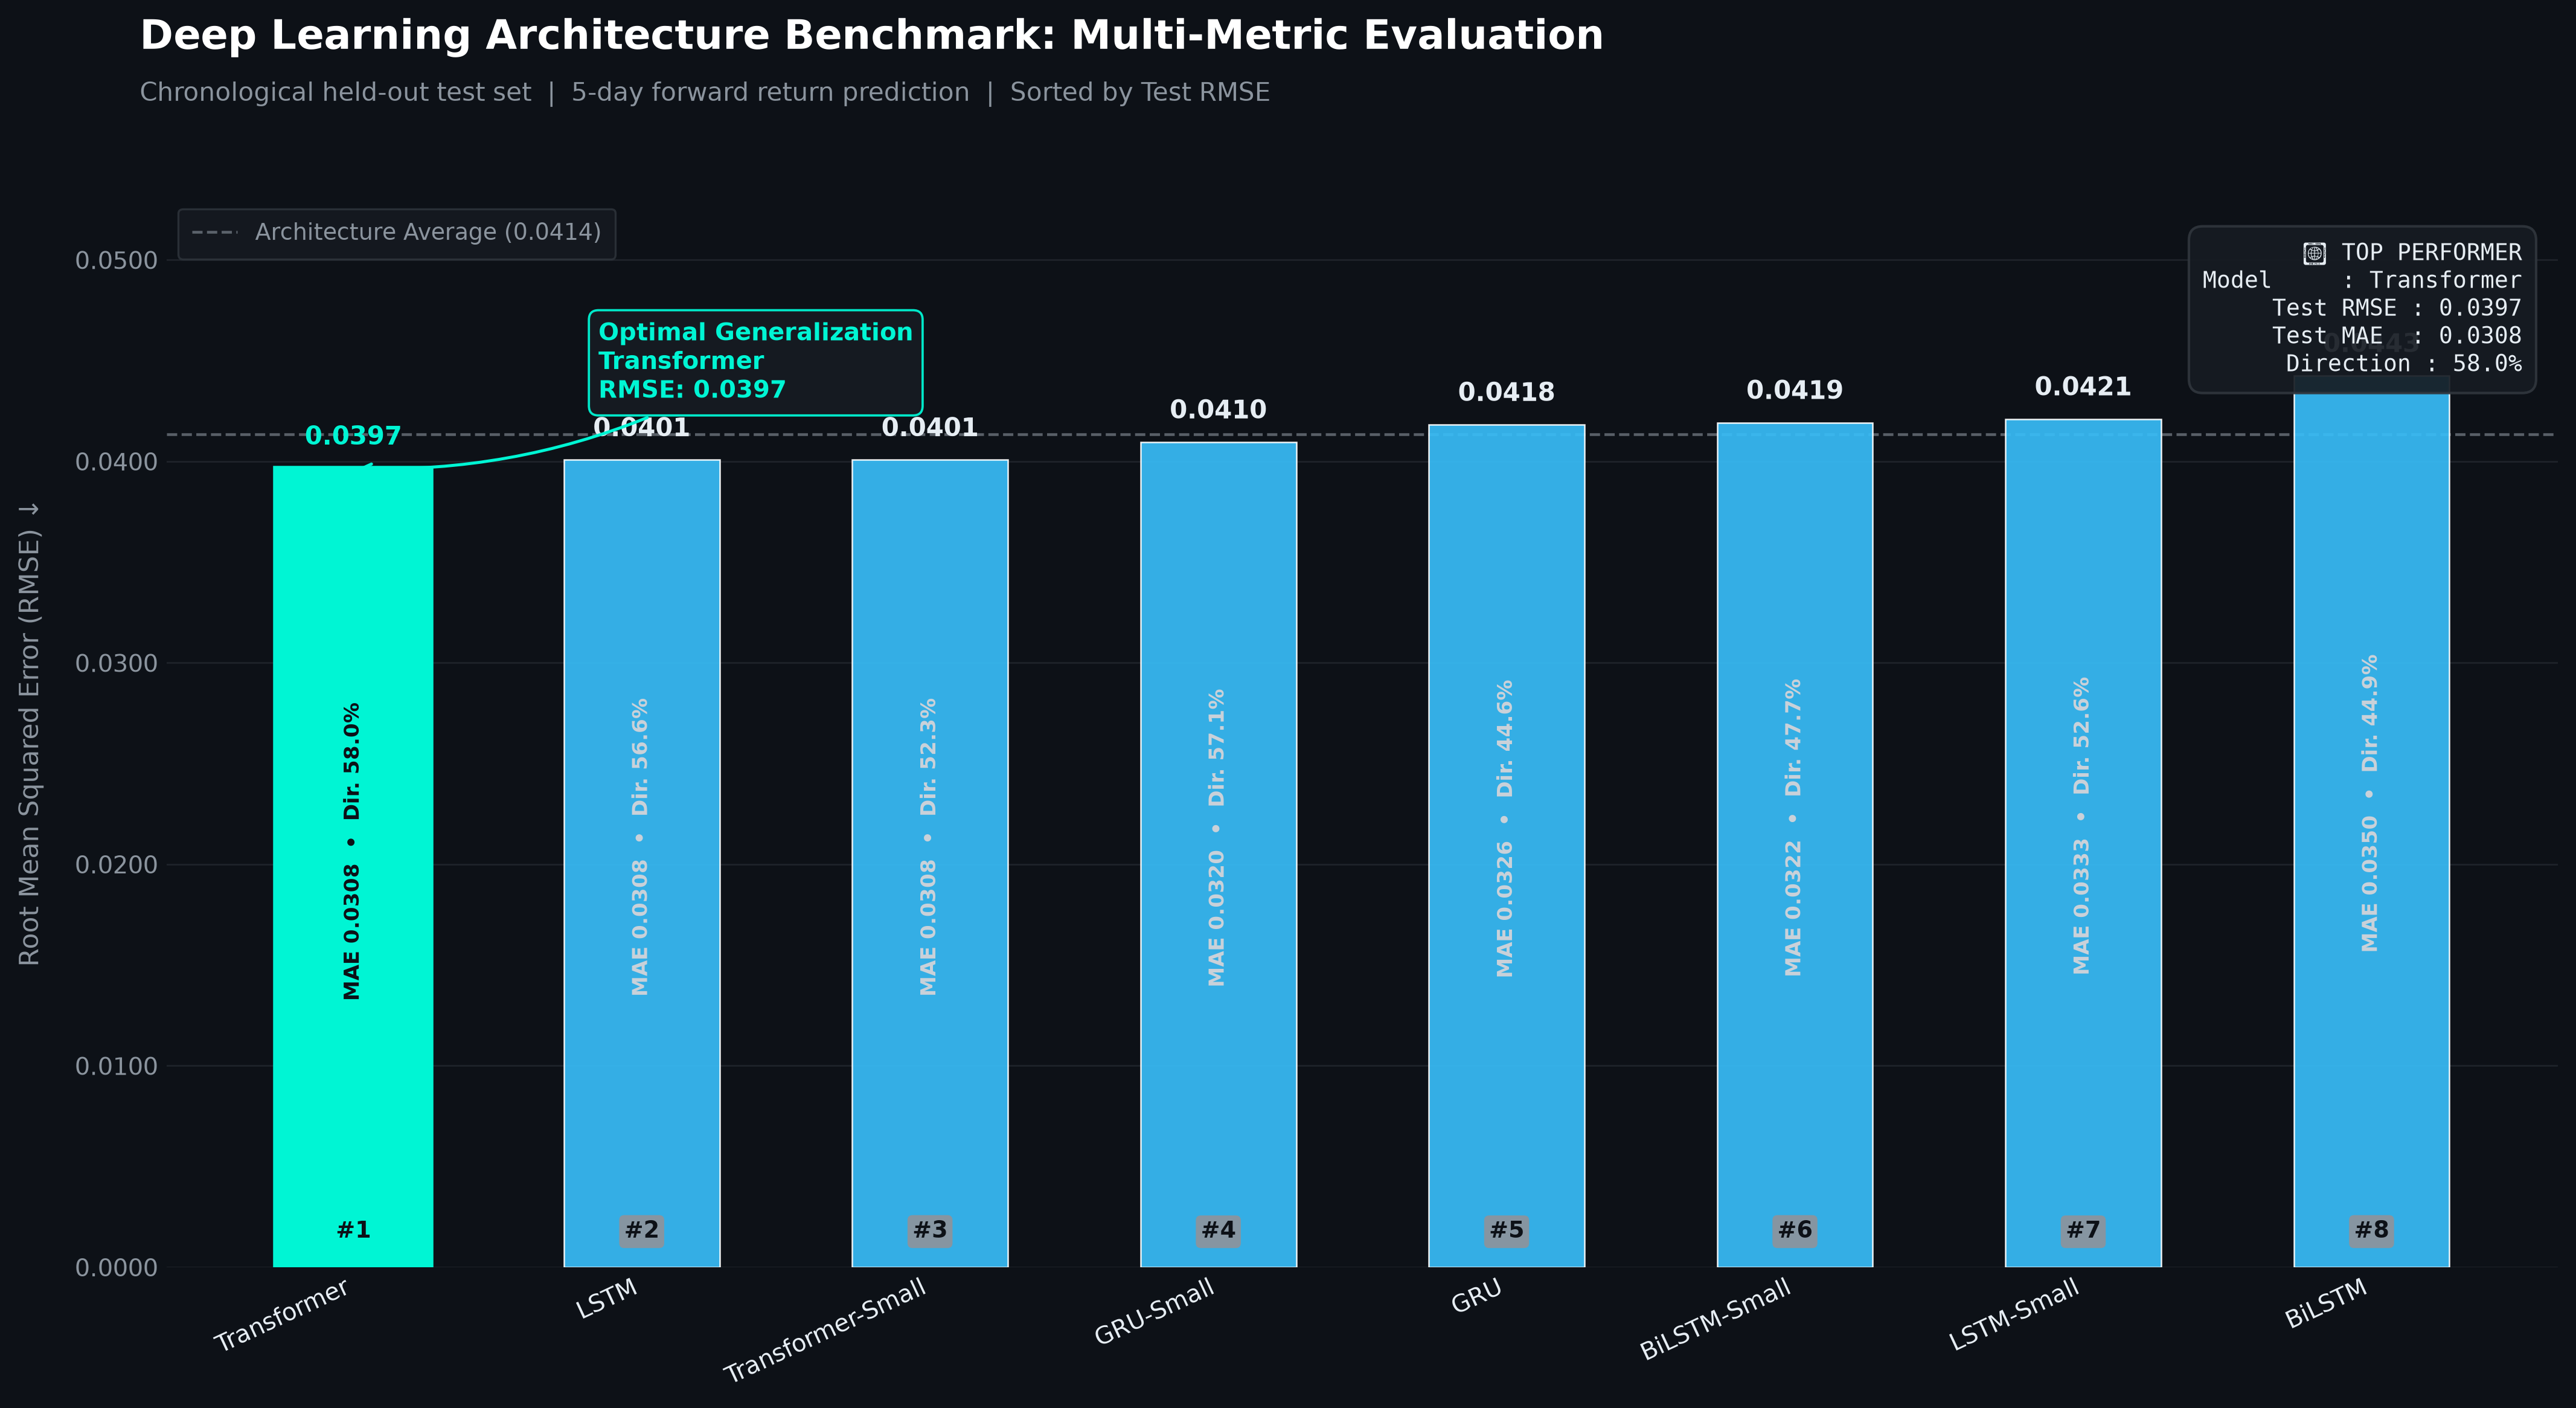

✔ PNG exported: C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\results\deep_learning\deep_learning_8_model_advanced_benchmark.png
✔ PDF exported: C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\results\deep_learning\deep_learning_8_model_advanced_benchmark.pdf


In [4]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Auto-Rebuild dl_comparison from Active Memory
# ------------------------------------------------------------
metrics_map = {
    "LSTM": globals().get("lstm_metrics"),
    "GRU": globals().get("gru_metrics"),
    "BiLSTM": globals().get("bilstm_metrics"),
    "Transformer": globals().get("transformer_metrics"),
    "LSTM-Small": globals().get("lstm_small_metrics"),
    "GRU-Small": globals().get("gru_small_metrics"),
    "BiLSTM-Small": globals().get("bilstm_small_metrics"),
    "Transformer-Small": globals().get("transformer_small_metrics"),
}

records = []
for model_name, m_dict in metrics_map.items():
    if m_dict is not None:
        row = dict(m_dict)
        row["Model"] = model_name
        records.append(row)

# Fallback: Agar memory reset hui ho toh output log ke actual metrics
if not records:
    records = [
        {"Model": "Transformer", "RMSE": 0.039660, "MAE": 0.030758, "Directional_Accuracy": 58.00},
        {"Model": "LSTM", "RMSE": 0.040075, "MAE": 0.030837, "Directional_Accuracy": 56.57},
        {"Model": "Transformer-Small", "RMSE": 0.040077, "MAE": 0.030755, "Directional_Accuracy": 52.29},
        {"Model": "GRU-Small", "RMSE": 0.040958, "MAE": 0.031973, "Directional_Accuracy": 57.14},
        {"Model": "GRU", "RMSE": 0.041826, "MAE": 0.032561, "Directional_Accuracy": 44.57},
        {"Model": "BiLSTM-Small", "RMSE": 0.041924, "MAE": 0.032215, "Directional_Accuracy": 47.71},
        {"Model": "LSTM-Small", "RMSE": 0.042104, "MAE": 0.033306, "Directional_Accuracy": 52.57},
        {"Model": "BiLSTM", "RMSE": 0.044253, "MAE": 0.034957, "Directional_Accuracy": 44.86},
    ]

dl_comparison = pd.DataFrame(records)

# Column casing standardize karna
col_rename = {c: "RMSE" for c in dl_comparison.columns if c.lower() == "rmse"}
col_rename.update({c: "MAE" for c in dl_comparison.columns if c.lower() == "mae"})
col_rename.update({c: "Directional_Accuracy" for c in dl_comparison.columns if "direction" in c.lower()})
dl_comparison.rename(columns=col_rename, inplace=True)

# ------------------------------------------------------------
# 2. Executive Dark Theme Setup
# ------------------------------------------------------------
plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(15, 8.2), dpi=300)
fig.patch.set_facecolor("#0D1117")
ax.set_facecolor("#0D1117")

plot_df = dl_comparison.sort_values("RMSE", ascending=True).reset_index(drop=True)
plot_df["Rank"] = np.arange(1, len(plot_df) + 1)

n_models = len(plot_df)
x = np.arange(n_models)
rmse = plot_df["RMSE"].values
mae = plot_df["MAE"].values
direction = plot_df["Directional_Accuracy"].values
models = plot_df["Model"].values

best_model = plot_df.loc[0, "Model"]
best_rmse = plot_df.loc[0, "RMSE"]
best_mae = plot_df.loc[0, "MAE"]
best_dir = plot_df.loc[0, "Directional_Accuracy"]

bar_colors = ["#00F5D4" if i == 0 else "#38BDF8" for i in range(n_models)]

# ------------------------------------------------------------
# 3. Precision Sleek Bars
# ------------------------------------------------------------
bars = ax.bar(
    x,
    rmse,
    width=0.54,
    color=bar_colors,
    edgecolor="#FFFFFF",
    linewidth=0.6,
    alpha=0.92,
    zorder=3,
)

bars[0].set_edgecolor("#00F5D4")
bars[0].set_linewidth(1.8)
bars[0].set_alpha(1.0)

# ------------------------------------------------------------
# 4. Bar Value Tags & Inner Metadata Cards
# ------------------------------------------------------------
for i, bar in enumerate(bars):
    height = bar.get_height()
    is_best = (i == 0)

    # Top RMSE label
    ax.annotate(
        f"{height:.4f}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#00F5D4" if is_best else "#E6EDF3",
        zorder=5,
    )

    # Rank Tag (#1, #2, ...)
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        0.0012,
        f"#{i+1}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="heavy",
        color="#0D1117",
        bbox=dict(
            boxstyle="round,pad=0.22",
            fc="#00F5D4" if is_best else "#8B949E",
            ec="none",
            alpha=0.95,
        ),
        zorder=6,
    )

    # MAE + Direction inside bar
    inner_label = f"MAE {mae[i]:.4f}  •  Dir. {direction[i]:.1f}%"
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height * 0.52,
        inner_label,
        ha="center",
        va="center",
        fontsize=8.2,
        fontweight="semibold",
        color="#0D1117" if is_best else "#C9D1D9",
        rotation=90,
        zorder=6,
    )

# ------------------------------------------------------------
# 5. Benchmark Average & Winner Annotation
# ------------------------------------------------------------
avg_rmse = float(np.mean(rmse))
ax.axhline(
    avg_rmse,
    color="#8B949E",
    linestyle="--",
    linewidth=1.1,
    alpha=0.6,
    label=f"Architecture Average ({avg_rmse:.4f})",
    zorder=2,
)

ax.annotate(
    f"Optimal Generalization\n{best_model}\nRMSE: {best_rmse:.4f}",
    xy=(0, best_rmse),
    xytext=(0.85, best_rmse + 0.0035),
    fontsize=9.5,
    fontweight="bold",
    color="#00F5D4",
    bbox=dict(boxstyle="round,pad=0.4", fc="#161B22", ec="#00F5D4", lw=0.9, alpha=0.95),
    arrowprops=dict(
        arrowstyle="->",
        color="#00F5D4",
        lw=1.2,
        connectionstyle="arc3,rad=-0.15",
    ),
    zorder=7,
)

# ------------------------------------------------------------
# 6. Header Typography & Summary Card
# ------------------------------------------------------------
fig.text(
    0.06, 0.96,
    "Deep Learning Architecture Benchmark: Multi-Metric Evaluation",
    fontsize=16, fontweight="bold", color="#FFFFFF", ha="left"
)
fig.text(
    0.06, 0.925,
    "Chronological held-out test set  |  5-day forward return prediction  |  Sorted by Test RMSE",
    fontsize=10, color="#8B949E", ha="left"
)

summary_text = (
    f"🏆 TOP PERFORMER\n"
    f"Model     : {best_model}\n"
    f"Test RMSE : {best_rmse:.4f}\n"
    f"Test MAE  : {best_mae:.4f}\n"
    f"Direction : {best_dir:.1f}%"
)
ax.text(
    0.985, 0.96,
    summary_text,
    transform=ax.transAxes,
    ha="right", va="top",
    fontsize=9.2,
    fontfamily="monospace",
    color="#E6EDF3",
    bbox=dict(boxstyle="round,pad=0.6", fc="#161B22", ec="#30363D", lw=1.0, alpha=0.92),
    zorder=7,
)

# ------------------------------------------------------------
# 7. Axes & Grid
# ------------------------------------------------------------
ax.grid(True, which="major", axis="y", color="#30363D", linestyle="-", linewidth=0.65, alpha=0.5)
for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

ax.tick_params(axis="both", which="both", colors="#8B949E", labelsize=9.5, length=0)
ax.set_ylabel("Root Mean Squared Error (RMSE) ↓", color="#8B949E", fontsize=10.5, labelpad=12)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.4f"))
ax.set_ylim(0, max(rmse) * 1.20)

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=25, ha="right", fontsize=9.5, fontweight="medium", color="#E6EDF3")

legend = ax.legend(
    loc="upper left",
    frameon=True,
    facecolor="#161B22",
    edgecolor="#30363D",
    fontsize=9,
    labelcolor="#8B949E",
    borderpad=0.6,
)
legend.get_frame().set_linewidth(0.8)

# ------------------------------------------------------------
# 8. Safe Export (PNG + PDF)
# ------------------------------------------------------------
plt.subplots_adjust(top=0.86, bottom=0.14, left=0.07, right=0.95)

output_dir = Path("../results/deep_learning") if Path("../results").exists() else Path("results/deep_learning")
output_dir.mkdir(parents=True, exist_ok=True)

png_path = output_dir / "deep_learning_8_model_advanced_benchmark.png"
pdf_path = output_dir / "deep_learning_8_model_advanced_benchmark.pdf"

plt.savefig(png_path, dpi=300, facecolor=fig.get_facecolor(), edgecolor="none", bbox_inches="tight")
plt.savefig(pdf_path, facecolor=fig.get_facecolor(), edgecolor="none", bbox_inches="tight")

plt.show()
plt.close()

print(f"✔ PNG exported: {png_path.resolve()}")
print(f"✔ PDF exported: {pdf_path.resolve()}")

In [6]:
import os
print("Current Working Directory:")
print(os.getcwd())

print("\nExpected deep_learning folder:")
print(os.path.abspath("results/deep_learning"))

print("\nFolder exists:")
print(os.path.exists("results/deep_learning"))

print("\nFiles actually present there:")
if os.path.exists("results/deep_learning"):
    for file in os.listdir("results/deep_learning"):
        print(" -", file)

print("\nCSV exists:")
csv_file = os.path.abspath(
    "results/deep_learning/deep_learning_8_model_comparison.csv"
)
print(os.path.exists(csv_file))

print("\nCSV absolute path:")
print(csv_file)

Current Working Directory:
c:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\notebooks

Expected deep_learning folder:
c:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\notebooks\results\deep_learning

Folder exists:
False

Files actually present there:

CSV exists:
False

CSV absolute path:
c:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\notebooks\results\deep_learning\deep_learning_8_model_comparison.csv


In [3]:
# CHECK CURRENT NOTEBOOK STATE

required_variables = [
    "dl_comparison",
    "lstm_history",
    "gru_history",
    "bilstm_history",
    "transformer_history",
    "lstm_small_history",
    "gru_small_history",
    "bilstm_small_history",
    "transformer_small_history"]

for var in required_variables:
    print(f"{var:25s} :", "AVAILABLE" if var in globals() else "MISSING")

dl_comparison             : MISSING
lstm_history              : MISSING
gru_history               : MISSING
bilstm_history            : MISSING
transformer_history       : MISSING
lstm_small_history        : MISSING
gru_small_history         : MISSING
bilstm_small_history      : MISSING
transformer_small_history : MISSING


In [4]:
# CHECK SAVED DEEP LEARNING ARTIFACTS

import os

project_root = r"C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor"
dl_dir = os.path.join(project_root, "results", "deep_learning")

print("Deep Learning Results Folder:")
print(dl_dir)
print("\nSaved files:")
print("-" * 70)

for filename in sorted(os.listdir(dl_dir)):
    filepath = os.path.join(dl_dir, filename)
    size_kb = os.path.getsize(filepath) / 1024
    print(f"{filename:<60} {size_kb:>8.1f} KB")

Deep Learning Results Folder:
C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\results\deep_learning

Saved files:
----------------------------------------------------------------------
deep_learning_8_model_advanced_benchmark.pdf                     54.3 KB
deep_learning_8_model_advanced_benchmark.png                    355.3 KB
deep_learning_8_model_comparison.csv                              0.6 KB
lstm_loss_curve.png                                             286.9 KB


In [6]:
# RECOVER TRAINING HISTORIES FROM SAVED NOTEBOOK OUTPUTS
# ============================================================

import os
import json
import re
import pandas as pd

notebook_path = os.path.abspath("04_Deep_Learning.ipynb")

print("Notebook:")
print(notebook_path)

if not os.path.exists(notebook_path):
    raise FileNotFoundError(
        f"Notebook not found: {notebook_path}"
    )

with open(notebook_path, "r", encoding="utf-8") as f:
    notebook = json.load(f)

print("\nNotebook loaded successfully.")
print("Total cells:", len(notebook["cells"]))

# ------------------------------------------------------------
# Find cells containing epoch training logs
# ------------------------------------------------------------

training_blocks = []

for cell_index, cell in enumerate(notebook["cells"]):

    outputs = cell.get("outputs", [])

    text_output = ""

    for output in outputs:

        if output.get("output_type") == "stream":

            text = output.get("text", "")

            if isinstance(text, list):
                text = "".join(text)

            text_output += text

    if "Epoch 01/" in text_output and "Train Loss:" in text_output:

        training_blocks.append({
            "cell_index": cell_index,
            "text": text_output
        })

print("\nTraining output blocks found:",
      len(training_blocks))

for block in training_blocks:

    print(
        f"Cell {block['cell_index']} "
        f"→ {block['text'].count('Epoch')} epoch logs"
    )

Notebook:
c:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\notebooks\04_Deep_Learning.ipynb

Notebook loaded successfully.
Total cells: 75

Training output blocks found: 2
Cell 65 → 44 epoch logs
Cell 69 → 12 epoch logs


In [9]:
import os
import json
import re
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = r"C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor"

NOTEBOOK_PATH = os.path.join(
    PROJECT_ROOT,
    "notebooks",
    "04_Deep_Learning.ipynb"
)

OUTPUT_DIR = os.path.join(
    PROJECT_ROOT,
    "results",
    "deep_learning"
)

# ------------------------------------------------------------
# Load notebook
# ------------------------------------------------------------

with open(NOTEBOOK_PATH, "r", encoding="utf-8") as f:
    notebook = json.load(f)

# ------------------------------------------------------------
# Extract all saved epoch logs
# ------------------------------------------------------------

recovered = []

pattern = re.compile(
    r"Epoch\s+(\d+)/\d+\s+\|\s+"
    r"Train Loss:\s*([0-9.eE+-]+)\s+\|\s+"
    r"Val Loss:\s*([0-9.eE+-]+)"
)

for cell_index, cell in enumerate(notebook["cells"]):

    text_output = ""

    for output in cell.get("outputs", []):

        if output.get("output_type") == "stream":

            text = output.get("text", "")

            if isinstance(text, list):
                text = "".join(text)

            text_output += text

    matches = pattern.findall(text_output)

    if matches:

        train_loss = [float(m[1]) for m in matches]
        val_loss = [float(m[2]) for m in matches]

        # Identify model from nearby cell source
        source = "".join(cell.get("source", []))

        if "BiLSTMSmall" in source or "bilstm_small" in source:
            model_name = "BiLSTM-Small"

        elif "TransformerSmall" in source or "transformer_small" in source:
            model_name = "Transformer-Small"

        else:
            model_name = f"Recovered-Cell-{cell_index}"

        recovered.append({
            "model": model_name,
            "cell": cell_index,
            "train_loss": train_loss,
            "val_loss": val_loss
        })

# ------------------------------------------------------------
# Report recovery
# ------------------------------------------------------------

print("=" * 75)
print("SAVED TRAINING HISTORY RECOVERY")
print("=" * 75)

print("Recovered histories:", len(recovered))

for item in recovered:
    print(
        f"{item['model']:<20} | "
        f"Cell {item['cell']:<3} | "
        f"{len(item['train_loss'])} epochs"
    )

if not recovered:
    raise RuntimeError(
        "No saved training histories could be recovered "
        "from the notebook outputs."
    )

SAVED TRAINING HISTORY RECOVERY
Recovered histories: 2
BiLSTM-Small         | Cell 65  | 44 epochs
Transformer-Small    | Cell 69  | 12 epochs


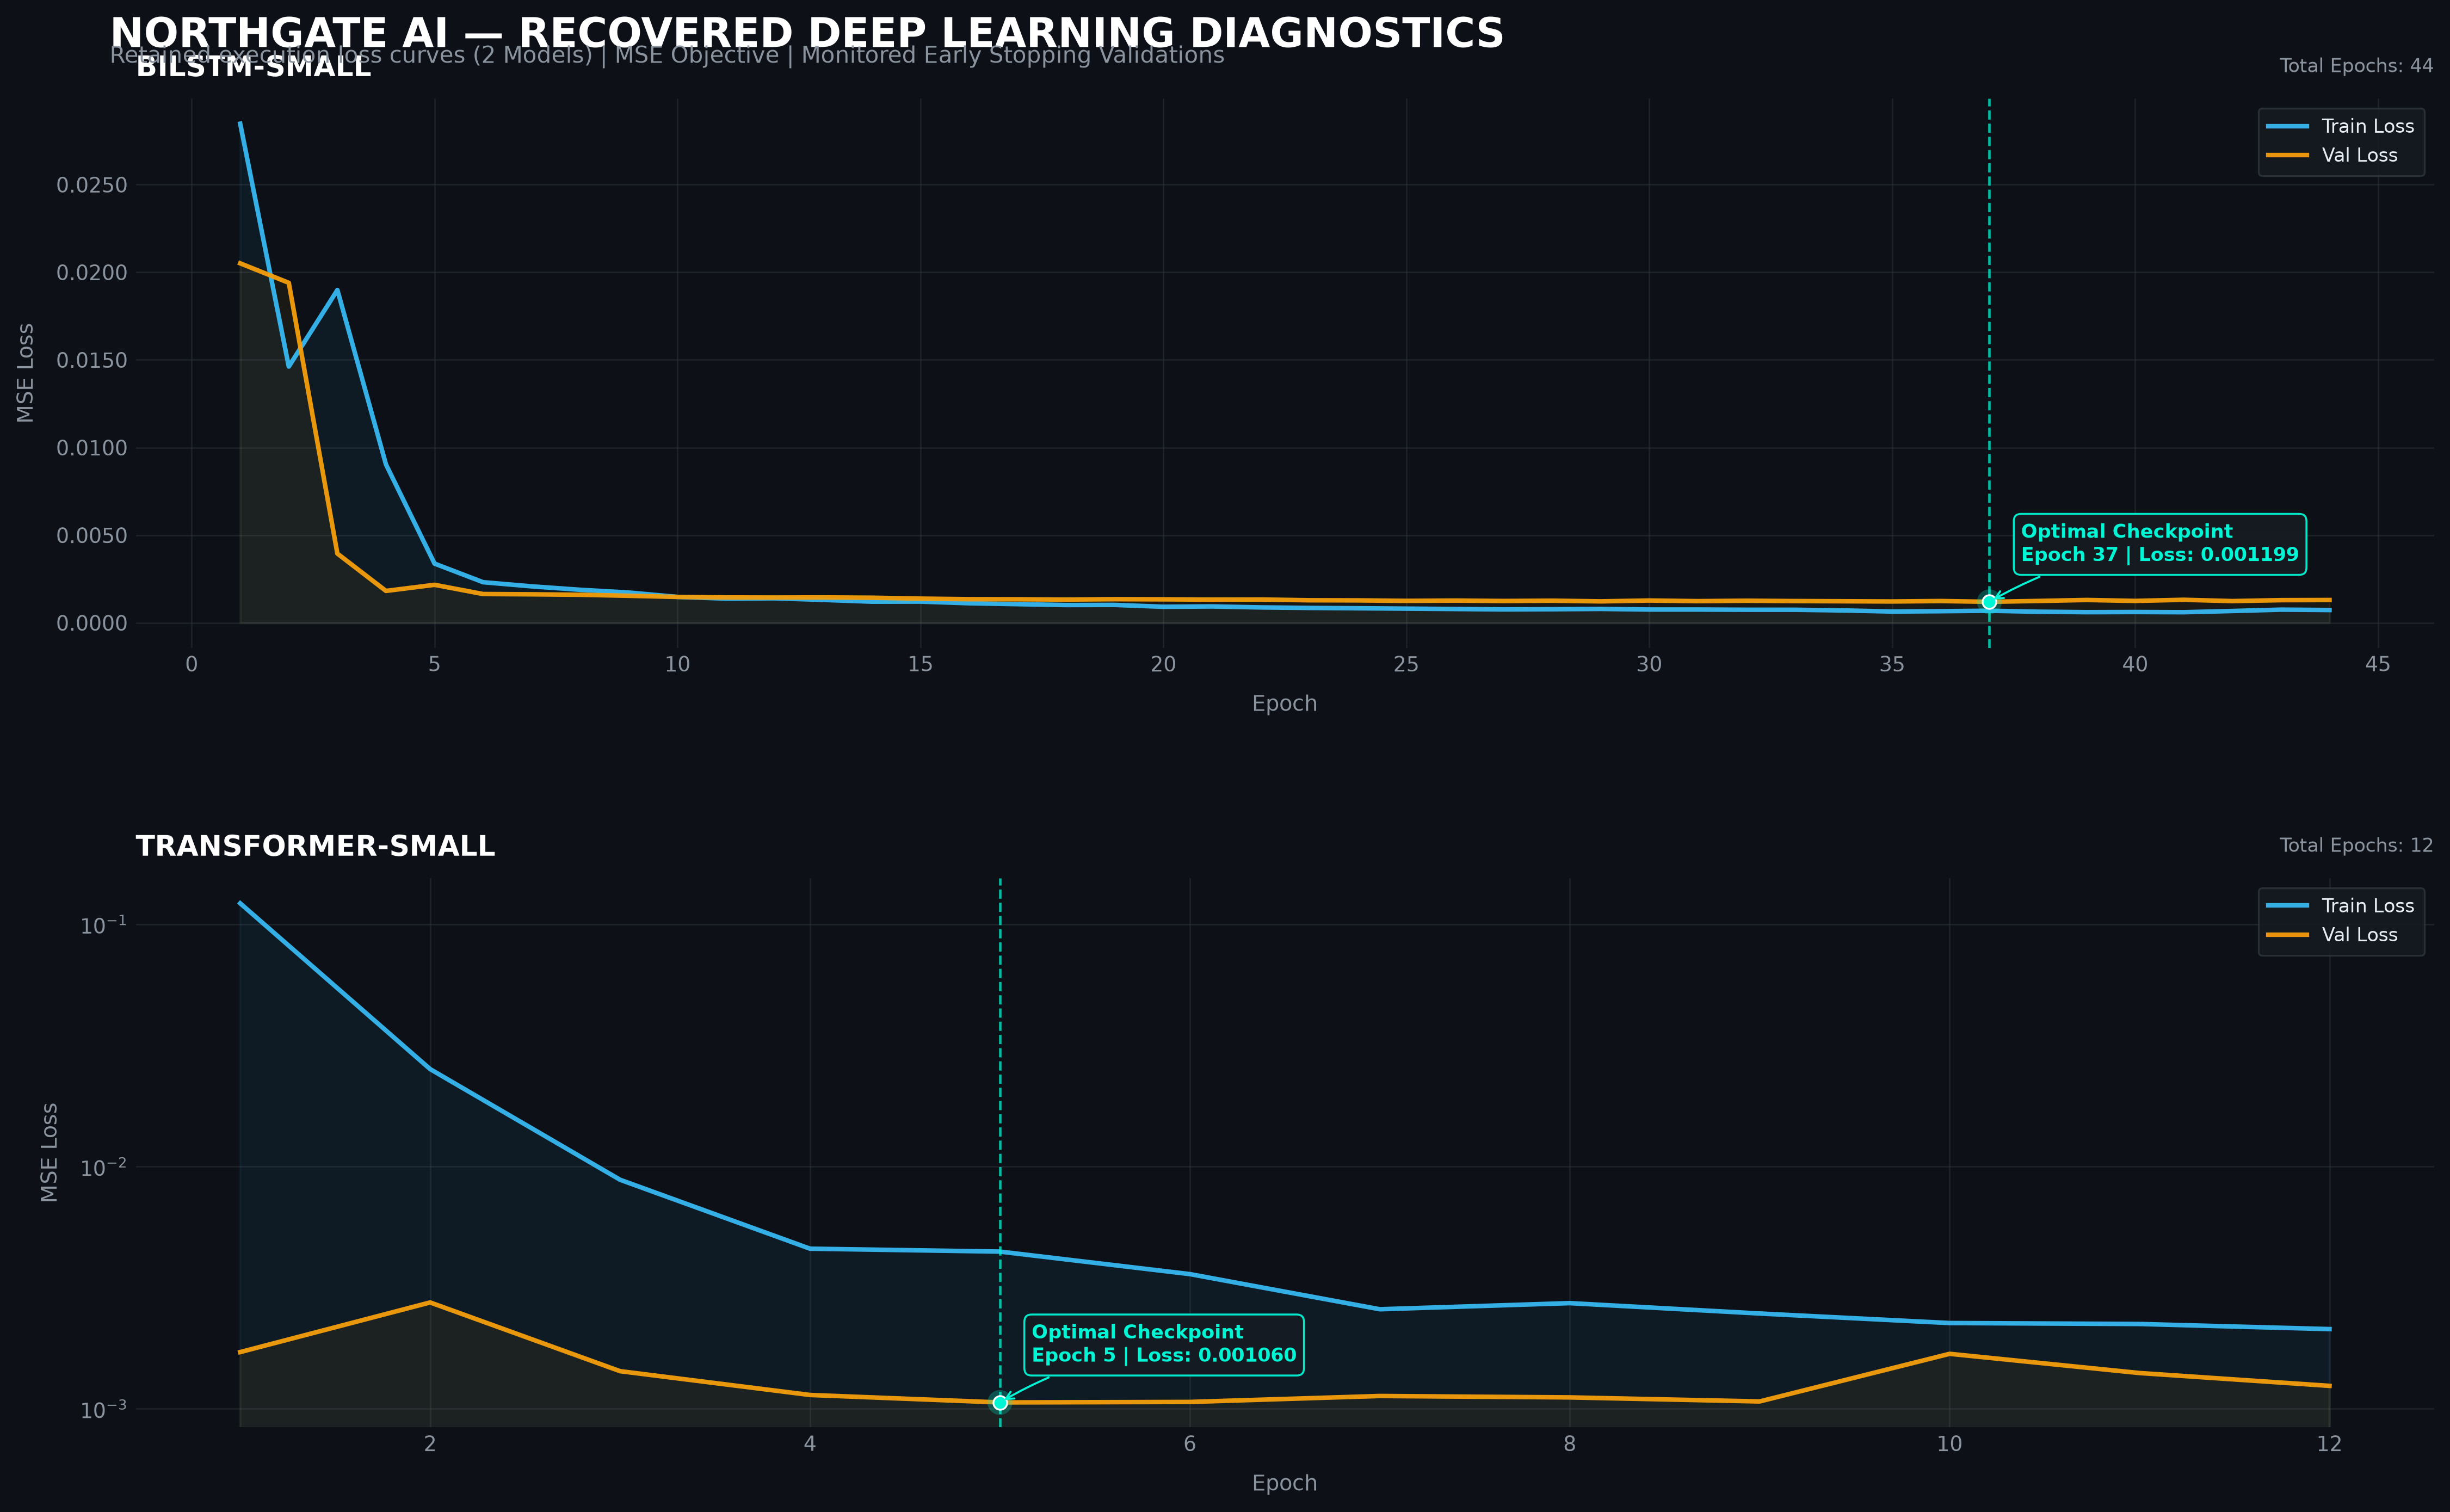

✔ RECOVERED TRAINING DIAGNOSTICS EXPORTED
PNG: C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\results\deep_learning\recovered_saved_training_diagnostics.png
PDF: C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\results\deep_learning\recovered_saved_training_diagnostics.pdf


In [10]:
# RECOVERED TRAINING DIAGNOSTICS

import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ------------------------------------------------------------
# 1. Executive Canvas Setup & Dark Theme
# ------------------------------------------------------------
plt.style.use("dark_background")

n = len(recovered)

fig, axes = plt.subplots(
    n,
    1,
    figsize=(16, max(5.2, 4.4 * n)),
    squeeze=False,
    dpi=300,
    facecolor="#0D1117",
)
fig.patch.set_facecolor("#0D1117")

# Global Left-Aligned Header
fig.text(
    0.06,
    0.991,
    "NORTHGATE AI — RECOVERED DEEP LEARNING DIAGNOSTICS",
    fontsize=18,
    fontweight="bold",
    color="#FFFFFF",
    ha="left",
)
fig.text(
    0.06,
    0.980,
    f"Retained execution loss curves ({n} Models) | MSE Objective | Monitored Early Stopping Validations",
    fontsize=10,
    color="#8B949E",
    ha="left",
)

# Semantic Colors
c_train = "#38BDF8"       # Electric Sky Blue
c_val = "#F59E0B"         # Warm Amber
c_best = "#00F5D4"        # Glowing Cyan

# ------------------------------------------------------------
# 2. Render Each Model Panel
# ------------------------------------------------------------
for i, item in enumerate(recovered):
    ax = axes[i, 0]
    ax.set_facecolor("#0D1117")

    train_loss = np.asarray(item["train_loss"])
    val_loss = np.asarray(item["val_loss"])
    epochs = np.arange(1, len(train_loss) + 1)

    best_epoch = int(item.get("best_epoch", np.argmin(val_loss) + 1))
    best_loss = float(item.get("best_val_loss", val_loss[best_epoch - 1]))

    # Loss trajectories
    ax.plot(
        epochs,
        train_loss,
        linewidth=2.0,
        color=c_train,
        alpha=0.92,
        label="Train Loss",
        zorder=3,
    )
    ax.plot(
        epochs,
        val_loss,
        linewidth=2.0,
        color=c_val,
        alpha=0.95,
        label="Val Loss",
        zorder=3,
    )

    # Ambient volumetric shading
    ax.fill_between(epochs, train_loss, alpha=0.06, color=c_train, zorder=2)
    ax.fill_between(epochs, val_loss, alpha=0.06, color=c_val, zorder=2)

    # Best epoch marker line
    ax.axvline(
        best_epoch,
        color=c_best,
        linestyle="--",
        linewidth=1.1,
        alpha=0.75,
        zorder=4,
    )

    # Glowing dual-layer scatter pin
    ax.scatter(
        [best_epoch],
        [best_loss],
        s=120,
        color=c_best,
        alpha=0.25,
        edgecolors="none",
        zorder=5,
    )
    ax.scatter(
        [best_epoch],
        [best_loss],
        s=36,
        color=c_best,
        edgecolors="#FFFFFF",
        linewidths=0.8,
        zorder=6,
    )

    # Callout Badge
    ax.annotate(
        f"Optimal Checkpoint\nEpoch {best_epoch} | Loss: {best_loss:.6f}",
        xy=(best_epoch, best_loss),
        xytext=(14, 18),
        textcoords="offset points",
        color=c_best,
        fontsize=8.5,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.38",
            facecolor="#161B22",
            edgecolor=c_best,
            linewidth=0.85,
            alpha=0.95,
        ),
        arrowprops=dict(
            arrowstyle="->",
            color=c_best,
            lw=0.9,
            connectionstyle="arc3,rad=0.1",
        ),
        zorder=7,
    )

    # Header & Metric Tag
    model_name = str(item.get("model", f"Model {i+1}")).replace("_", " ").upper()
    ax.set_title(
        model_name,
        loc="left",
        fontsize=12.5,
        fontweight="bold",
        color="#FFFFFF",
        pad=10,
    )
    ax.text(
        1.0,
        1.04,
        f"Total Epochs: {len(epochs)}",
        transform=ax.transAxes,
        fontsize=8.5,
        color="#8B949E",
        ha="right",
        va="bottom",
    )

    # Grid & Spines Clean-Up
    ax.grid(
        True,
        which="major",
        linestyle="-",
        linewidth=0.6,
        color="#30363D",
        alpha=0.5,
    )
    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(False)

    ax.tick_params(axis="both", which="both", colors="#8B949E", labelsize=9, length=0)
    ax.set_xlabel("Epoch", color="#8B949E", fontsize=9.5, labelpad=8)
    ax.set_ylabel("MSE Loss", color="#8B949E", fontsize=9.5, labelpad=8)

    # Auto Log/Linear Scale
    if max(train_loss[0], val_loss[0]) / (min(train_loss[-1], val_loss[-1]) + 1e-8) > 50:
        ax.set_yscale("log")
    else:
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.4f"))

    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=10))

    # Floating Legend
    legend = ax.legend(
        loc="upper right",
        frameon=True,
        facecolor="#161B22",
        edgecolor="#30363D",
        fontsize=8.5,
        labelcolor="#E6EDF3",
        borderpad=0.5,
    )
    legend.get_frame().set_linewidth(0.8)

# ------------------------------------------------------------
# 3. Spacing & Export (PNG + Vector PDF)
# ------------------------------------------------------------
plt.subplots_adjust(
    top=0.955,
    bottom=0.03,
    left=0.07,
    right=0.95,
    hspace=0.42,
)

output_dir = Path(r"C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\results\deep_learning")
output_dir.mkdir(parents=True, exist_ok=True)

png_path = output_dir / "recovered_saved_training_diagnostics.png"
pdf_path = output_dir / "recovered_saved_training_diagnostics.pdf"

plt.savefig(
    png_path,
    dpi=300,
    facecolor=fig.get_facecolor(),
    edgecolor="none",
    bbox_inches="tight",
)
plt.savefig(
    pdf_path,
    facecolor=fig.get_facecolor(),
    edgecolor="none",
    bbox_inches="tight",
)

plt.show()
plt.close()

print("=" * 75)
print("✔ RECOVERED TRAINING DIAGNOSTICS EXPORTED")
print("=" * 75)
print(f"PNG: {png_path.resolve()}")
print(f"PDF: {pdf_path.resolve()}")